In [54]:
import numpy as np
import matplotlib.pyplot as plt
import re
import surfinBH
import lal
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
import pandas as pd
import gwsurrogate as gws
import warnings
from tqdm.notebook import tqdm
lal.swig_redirect_standard_output_error(False)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [3]:
fit_1 = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

Loaded NRSur7dq4EmriRemnant fit.


In [4]:
q = 4        
m1 = q / (1 + q) 
m2 = 1 / (1 + q) 
eta = (m1 * m2) 

chi1_z = 0.4
chi2_z = -0.2

S1 = chi1_z * (m1**2)
S2 = chi2_z * (m2**2)

a_fit_1 = np.linspace(100.0,7.0, 1000)

In [5]:
spin1 = [0.0, 0.0, chi1_z]
spin2 = [0.0, 0.0, chi2_z]
mf_surr, chif_vec, *_ = fit_1.all(q, spin1, spin2)
chif_surr = np.linalg.norm(chif_vec)
Jf_surr = chif_surr * (mf_surr**2)

S_surr_final = entropy(mf_surr, Jf_surr)
print(S_surr_final)

10.306098068917818


2PN ANALYSIS

In [6]:
# function to calculate the maximum entropy at 2PN
# arXiv:1310.1528
# arXiv:gr-qc/0605140

def get_max_2PN(q, chi1_z, chi2_z, a):
    
    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)
    eta = m1 * m2
    delta = m1 - m2  

    S1 = chi1_z * (m1**2)
    S2 = chi2_z * (m2**2)
    
    S_L = S1 + S2
    Sigma_L = chi1_z * m1 - chi2_z * m2
    
    S_ss = S1 * S2

    e1 = -3.0/4.0 - eta/12.0
    e1_5 = (14.0/3.0) * S_L + 2.0 * delta * Sigma_L
    e2 = -27.0/8.0 + (19.0/8.0)*eta - (eta**2)/24.0 - S_ss

    l1 = 3.0/2.0 + eta/6.0
    l1_5 = -(35.0/6.0) * S_L - 2.5 * delta * Sigma_L
    l2 = 27.0/8.0 - (19.0/8.0)*eta + (eta**2)/24.0 + 0.5 * S_ss

    a_arr = np.asarray(a)

    x = 1.0 / a_arr

    E_bind_2PN = - (eta * x / 2.0) * (1.0 + e1*x + e1_5*(x**1.5) + e2*(x**2))
    M_tot_2PN = 1.0 + E_bind_2PN 

    L_orb_2PN = (eta / np.sqrt(x)) * (1.0 + l1*x + l1_5*(x**1.5) + l2*(x**2))
    J_tot_2PN = L_orb_2PN + S_L 
        
    S_inst = entropy(M_tot_2PN, J_tot_2PN)
    
    valid = S_inst[~np.isnan(S_inst)]
    max_val = np.max(valid) if len(valid) > 0 else np.nan
    
    return M_tot_2PN, J_tot_2PN, S_inst, max_val

In [7]:
M_array, J_array, S, max_val = get_max_2PN(q, chi1_z, chi2_z, a_fit_1)
print(max_val)
print(S_surr_final)
print( 'delta S = ', np.abs(max_val - S_surr_final))

10.151430381731053
10.306098068917818
delta S =  0.15466768718676427


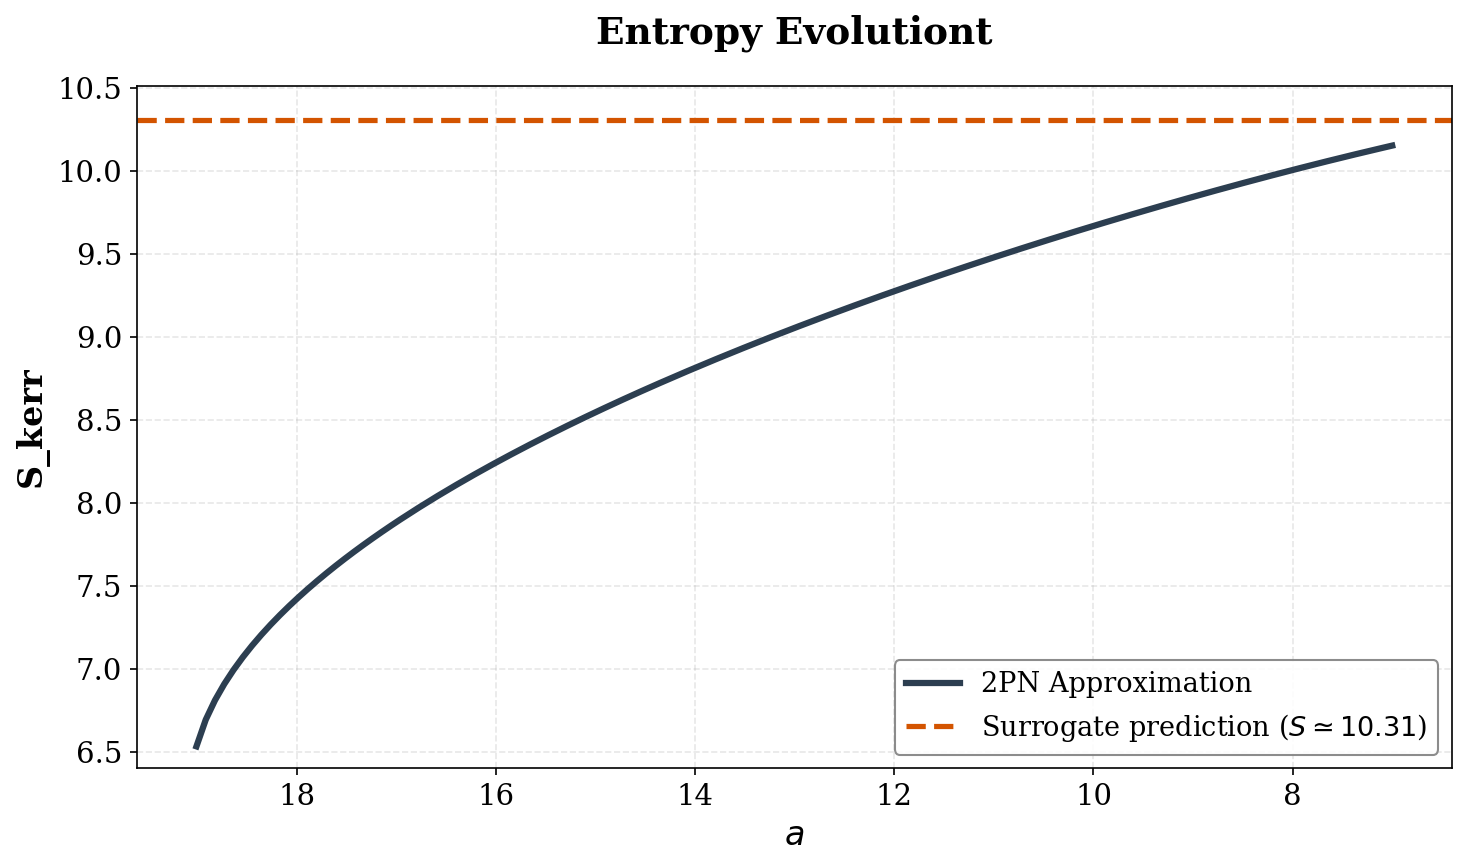

In [9]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(a_fit_1, S, color='#2c3e50', lw=3.0, label=r'2PN Approximation')

ax.axhline(S_surr_final, color='#d35400', linestyle='--', lw=2.5, 
           label=rf'Surrogate prediction ($S \simeq {S_surr_final:.2f}$)')
ax.invert_xaxis()
ax.set_xlabel(r'$a$', fontweight='bold')
ax.set_ylabel(r'S_kerr', fontweight='bold')
ax.set_title(r'Entropy Evolutiont', fontweight='bold', pad=20)
y_min = min(np.nanmin(S), S_surr_final) * 0.98
y_max = max(np.nanmax(S), S_surr_final) * 1.02
ax.set_ylim(y_min, y_max)
ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='gray', framealpha=0.9)
plt.tight_layout()
plt.show()

PADE' INTERPOLATION

In [210]:

def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)


def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)


def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)


def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [12]:
valid_mask = ~np.isnan(S)
a_valid = a_fit_1[valid_mask]
M_valid = M_array[valid_mask]
J_valid = J_array[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

initial_guess = [1.0, 1.0, 1.0, 1.0]
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

popt_M, _ = curve_fit(pade_2_1, x_fit, M_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)
popt_J, _ = curve_fit(pade_2_1, x_fit, J_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = pade_2_1(x_extrap, *popt_M)
J_extrap = pade_2_1(x_extrap, *popt_J)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Padé at a =      {a_max_entropy:.3f}")
print("2PN Padé max entropy =       ", S_max_entropy)
print("Predicted entropy =          ", S_surr_final)
print("Delta S =                    ", np.abs(S_max_entropy - S_surr_final))

Maximum with Padé at a =      3.450
2PN Padé max entropy =        10.46622264028822
Predicted entropy =           10.306098068917818
Delta S =                     0.16012457137040315


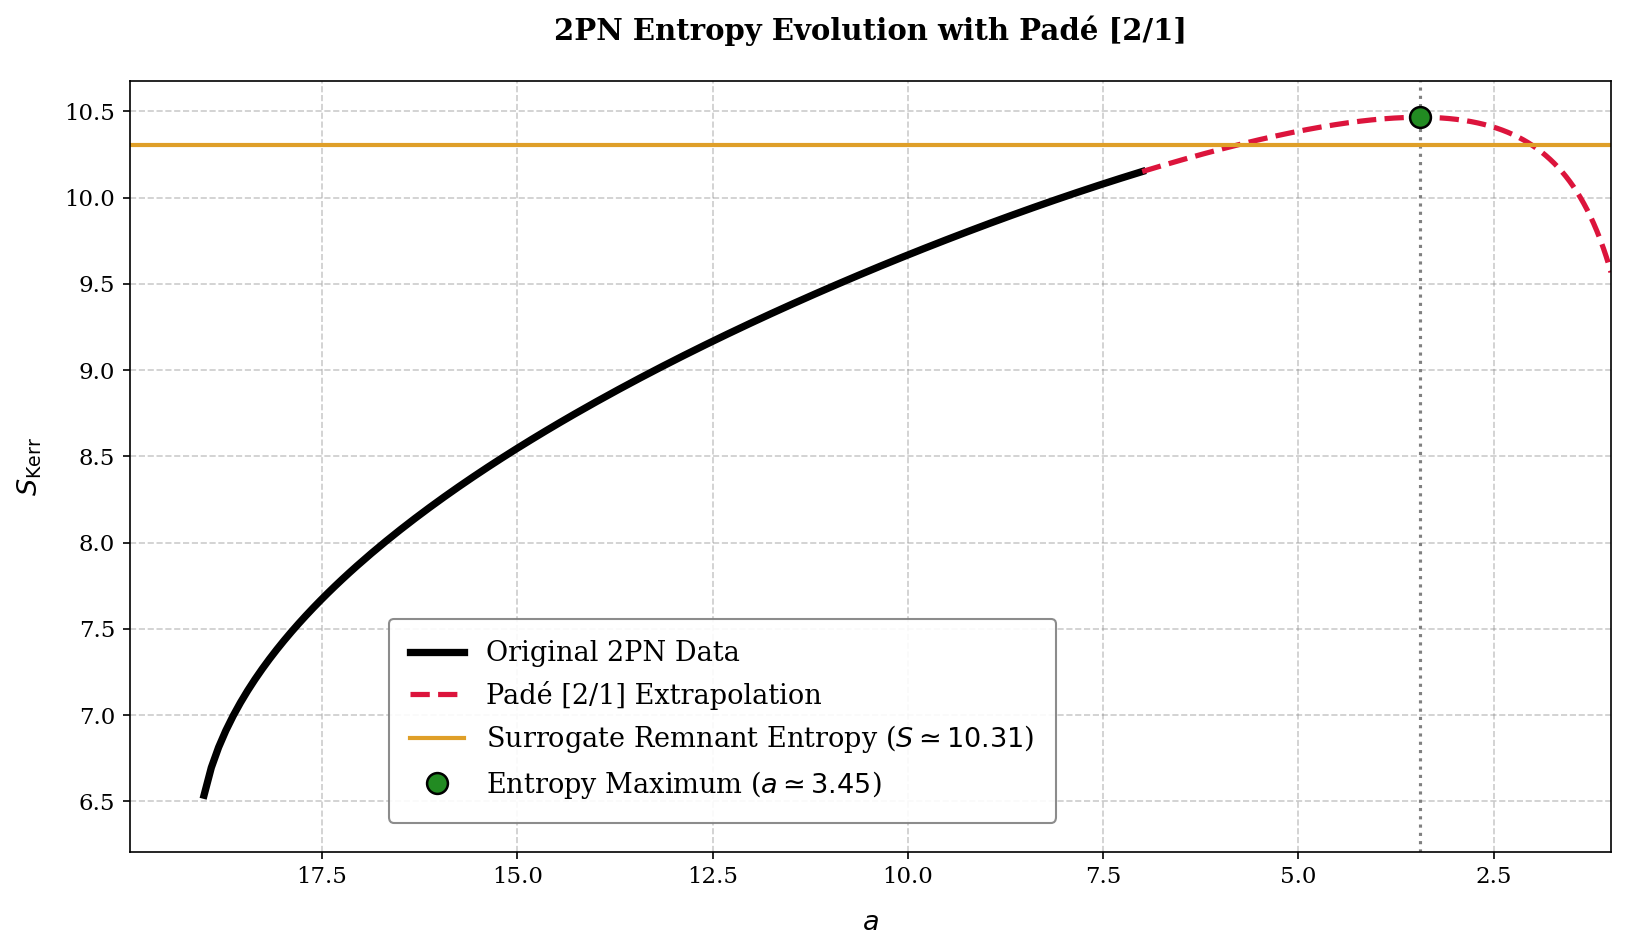

In [13]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Padé [2/1] Extrapolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Padé [2/1]', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

POLYNOMIAL INTERPOLATION

In [14]:
valid_mask = ~np.isnan(S)
a_valid = a_fit_1[valid_mask]
M_valid = M_array[valid_mask]
J_valid = J_array[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)
degree = 4

poly_M = np.poly1d(np.polyfit(x_fit, M_fit, degree))
poly_J = np.poly1d(np.polyfit(x_fit, J_fit, degree))

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = poly_M(x_extrap)
J_extrap = poly_J(x_extrap)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Taylor at a =         {a_max_entropy:.3f}")
print("2PN Taylor max entropy =          ", S_max_entropy)
print("Predicted entropy =               ", S_surr_final)
print("Delta S =                         ", np.abs(S_max_entropy - S_surr_final))

Maximum with Taylor at a =         4.934
2PN Taylor max entropy =           10.336638765179075
Predicted entropy =                10.306098068917818
Delta S =                          0.030540696261256883


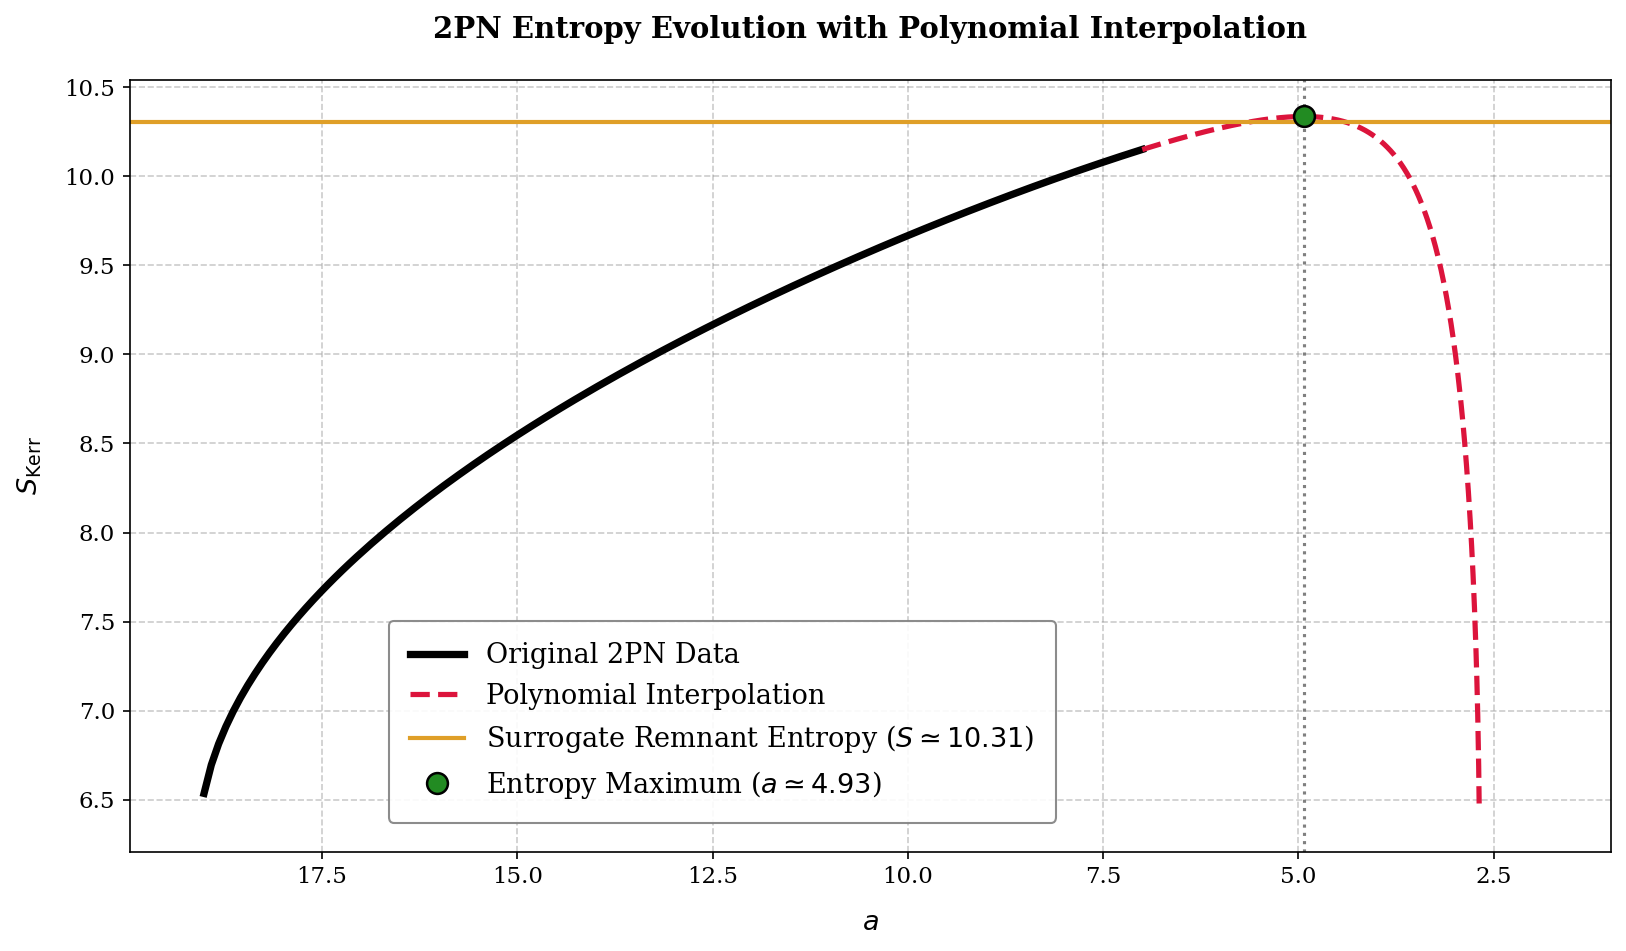

In [15]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Polynomial Interpolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Polynomial Interpolation', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

NR ANALYSIS

In [16]:
q_NR = 2
chi1_NR = 0.2
chi2_NR = 0.3

a_NR = np.linspace(100.0, 6.0, 10000) 

spin1 = [0.0, 0.0, chi1_NR]
spin2 = [0.0, 0.0, chi2_NR]

In [17]:
sur_wave_aligned = gws.LoadSurrogate('NRSur7dq4')
sur_remnant_aligned = surfinBH.LoadFits('NRSur3dq8Remnant')

Loaded NRSur7dq4 model
Loaded NRSur3dq8Remnant fit.


In [18]:
def simulate_conjecture_2PN(q_input, chi1_z, chi2_z, f_low=0.01):

    if q_input < 1.0:
        q = 1.0 / q_input
        chiA = chi2_z
        chiB = chi1_z
    else:
        q = q_input
        chiA = chi1_z
        chiB = chi2_z

    spin1 = [0.0, 0.0, chiA]
    spin2 = [0.0, 0.0, chiB]
    t, h, _ = sur_wave_aligned(q, spin1, spin2, dt=0.1, f_low=f_low)
    
    
    h22 = h[(2, 2)]
    phase_22 = np.unwrap(np.angle(h22))
    omega_22 = np.abs(np.gradient(phase_22, t))
    omega_orb = omega_22 / 2.0
    r_inst = (np.maximum(omega_orb, 1e-8))**(-2.0 / 3.0)
    

    E_dot = np.zeros_like(t)
    J_dot = np.zeros_like(t)
    
    for (l, m), h_lm in h.items():
        h_dot = np.gradient(h_lm, t)
        E_dot += np.abs(h_dot)**2
        J_dot += m * np.imag(h_lm * np.conj(h_dot))
        
    E_dot /= (16.0 * np.pi)
    J_dot /= (16.0 * np.pi)
    
    E_rad = cumulative_trapezoid(E_dot, t, initial=0)
    J_rad = cumulative_trapezoid(J_dot, t, initial=0)
    
   
    r_0 = r_inst[0]
    M_init_arr, J_init_arr, _, _ = get_max_2PN(q, chiA, chiB, [r_0])
    M_init = M_init_arr[0]
    J_init = J_init_arr[0]
    

    M_inst = M_init - E_rad
    J_inst = J_init - J_rad
    a_inst = np.abs(J_inst) / (M_inst**2)
    
    valid = a_inst <= 1.0
    if not np.any(valid):
        return None
    
    t_valid = t[valid]
    a_valid = a_inst[valid]
    M_valid = M_inst[valid]
    J_valid = J_inst[valid]  
    r_valid = r_inst[valid]
    
    S_Kerr = entropy(M_valid, J_valid)
    
    return {
        't': t_valid, 
        'a_inst': a_valid, 
        'S_Kerr': S_Kerr,   
        'r': r_valid,
        'M': M_valid,
        'J': J_valid
    }

In [19]:
risultato = simulate_conjecture_2PN(q_NR, chi1_NR, chi2_NR)

In [23]:
S_plot = risultato['S_Kerr']
t_array, r_array = risultato['t'], risultato['r']

idx_merger_raw = np.argmin(np.abs(t_array))
dr = np.diff(r_array)
rimbalzi = np.where(dr[idx_merger_raw:] > 0)[0]
idx_end = idx_merger_raw + rimbalzi[0] if len(rimbalzi) > 0 else len(r_array) - 1
    
r_clean, S_clean, t_clean = r_array[:idx_end], S_plot[:idx_end], t_array[:idx_end]

idx_merger = np.argmin(np.abs(t_clean))
r_merger = r_clean[idx_merger]
idx_peak = np.nanargmax(S_clean)
r_peak = r_clean[idx_peak]
delta_r = np.abs(r_merger - r_peak)

S_plot = risultato['S_Kerr']
t_array, r_array = risultato['t'], risultato['r']

idx_merger_raw = np.argmin(np.abs(t_array))
dr = np.diff(r_array)
rimbalzi = np.where(dr[idx_merger_raw:] > 0)[0]
idx_end = idx_merger_raw + rimbalzi[0] if len(rimbalzi) > 0 else len(r_array) - 1
    
r_clean, S_clean, t_clean = r_array[:idx_end], S_plot[:idx_end], t_array[:idx_end]

idx_merger = np.argmin(np.abs(t_clean))
r_merger = r_clean[idx_merger]
idx_peak = np.nanargmax(S_clean)
r_peak = r_clean[idx_peak]
delta_r = np.abs(r_merger - r_peak)

print(f"Radius at Merger :              a = {r_merger:.4f} M")
print(f"Radius at Entropy Peak:         a = {r_peak:.4f} M")
print(f"Delta a:                        Δa = {delta_r:.4f} M")

Radius at Merger :              a = 3.0931 M
Radius at Entropy Peak:         a = 2.7142 M
Delta a:                        Δa = 0.3789 M


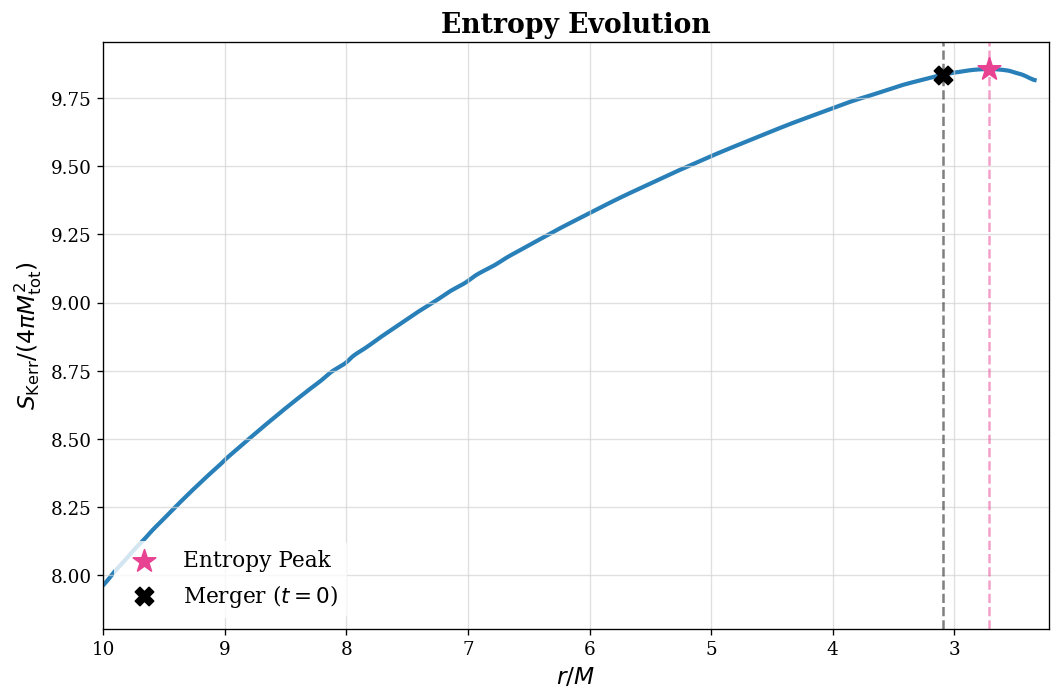

In [24]:
plt.figure(figsize=(9, 6), dpi=120)
plt.plot(r_clean, S_clean, lw=2.5, color='#2980b9', zorder=1)

plt.scatter(r_peak, S_clean[idx_peak], color='#e84393', s=200, marker='*', zorder=4, label='Entropy Peak')
plt.scatter(r_merger, S_clean[idx_merger], color='black', s=120, marker='X', zorder=3, label=r'Merger ($t=0$)')
plt.axvline(r_peak, color='#e84393', linestyle='--', alpha=0.5, zorder=2)
plt.axvline(r_merger, color='black', linestyle='--', alpha=0.5, zorder=2)

plt.gca().invert_xaxis()
plt.xlim(10.0, r_clean[-1] * 0.95)
plt.ylim(np.min(S_clean[r_clean <= 10.0]) * 0.98, S_clean[idx_peak] * 1.01)

plt.xlabel(r'$r/M$', fontsize=14)
plt.ylabel(r'$S_{\mathrm{Kerr}} / (4\pi M_{\mathrm{tot}}^2)$', fontsize=14) 
plt.title('Entropy Evolution', fontsize=16, fontweight='bold')
plt.legend(loc='lower left', fontsize=13, frameon=True, edgecolor='none')
plt.grid(True, linestyle='-', color='lightgray', alpha=0.7)
plt.tight_layout()
plt.show()

BREAKDOWN OF THE POST-NEWTONIAN FORMALISM

Symmetric Spin

In [25]:
def analyze_configuration_symmetric(q, chi_val,a):
    
    spin1 = [0.0, 0.0, chi_val]
    spin2 = [0.0, 0.0, chi_val]
    
    mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
    Jf = np.linalg.norm(chif_vec) * (mf**2)
    S_final = 2.0 * np.pi * (mf**2) * (1.0 + np.sqrt(1.0 - (Jf/(mf**2))**2))

    M_arr, J_arr, S_arr, max_2pn = get_max_2PN(q, chi_val, chi_val, a)
    
    return {
        "q": q,
        "chi": chi_val,
        "S_NR": S_final,
        "S_2PN_max": max_2pn,
        "Delta_S": np.abs(max_2pn - S_final)
    }

In [26]:
q_list = np.linspace(1,8,30)
chi_list = np.linspace(0.1,0.8,30)
a_2 = np.linspace(100.0,7.0, 1000)

results = []

for q in q_list:
    for chi in chi_list:
        try:
            res = analyze_configuration_symmetric(q, chi,a_2)
            results.append(res)
        except Exception as e:
            print(f"Skipping q={q}, chi={chi}: {e}")

df_results = pd.DataFrame(results)

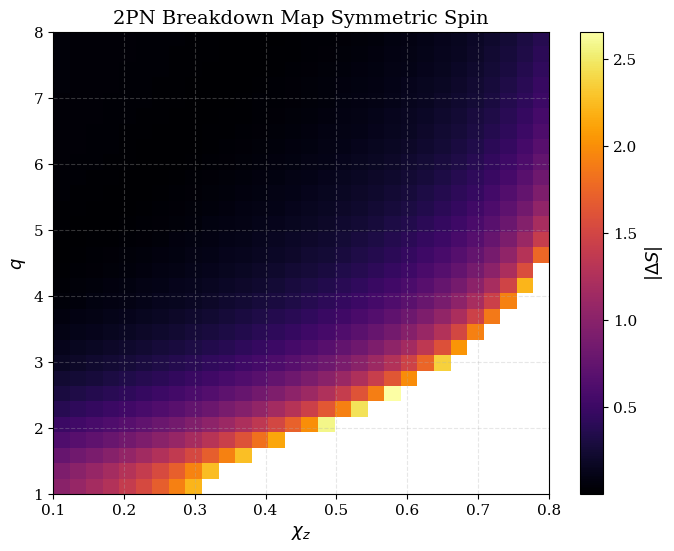

In [27]:

pivot_data = df_results.pivot(index="q", columns="chi", values="Delta_S")

plt.figure(figsize=(8, 6))
plt.imshow(pivot_data, aspect='auto', cmap='inferno', origin='lower',
           extent=[min(chi_list), max(chi_list), min(q_list), max(q_list)])
plt.colorbar(label=r'$|\Delta S|$')
plt.xlabel(r'$\chi_z$')
plt.ylabel(r'$q$')
plt.title('2PN Breakdown Map Symmetric Spin')
plt.show()

Asymmetric spin

In [28]:
def analyze_configuration_asymmetric(q, chi1, chi2, a):

    spin1 = [0.0, 0.0, chi1]
    spin2 = [0.0, 0.0, chi2]
    
    mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
        
    chi_f_nr = np.linalg.norm(chif_vec)
    S_final_nr = entropy(mf,chi_f_nr)
    M_arr, J_arr, S_arr, max_2pn = get_max_2PN(q, chi1, chi2, a)
    
    return {
        "q": q,
        "delta_chi": chi1 - chi2,
        "chi_avg": (chi1 + chi2) / 2.0, # Utile per tenere costante il momento
        "Delta_S": np.abs(max_2pn - S_final_nr)
    }

In [29]:
results = []
spin_range = np.linspace(-0.8, 0.8, 10) 
q_range = np.linspace(1,8,10)
a_3 = np.linspace(100.0,7.0, 1000)

for q in q_range:
    for chi1 in spin_range:
        for chi2 in spin_range:
            if abs(chi1) > 0.8 or abs(chi2) > 0.8: continue
            
            res = analyze_configuration_asymmetric(q, chi1, chi2, a_3)
            results.append(res)

df = pd.DataFrame(results)

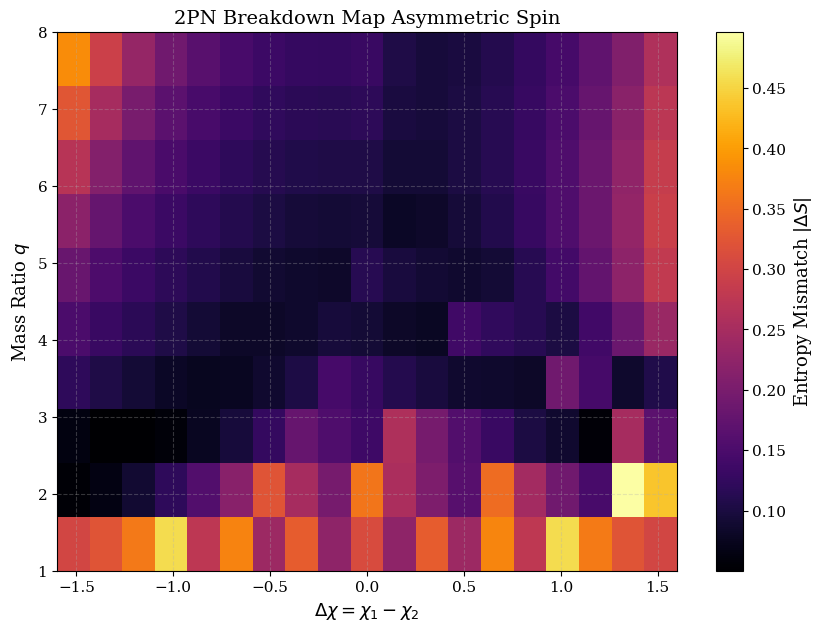

In [30]:
df['delta_chi_rounded'] = df['delta_chi'].round(1)
pivot_map = df.pivot_table(index="q", columns="delta_chi_rounded", values="Delta_S", aggfunc='mean')

# Plot
plt.figure(figsize=(10, 7))
plt.imshow(pivot_map, aspect='auto', origin='lower', cmap='inferno',
           extent=[pivot_map.columns.min(), pivot_map.columns.max(), 
                   pivot_map.index.min(), pivot_map.index.max()])
plt.colorbar(label=r'Entropy Mismatch $|\Delta S|$')
plt.xlabel(r'$\Delta \chi = \chi_1 - \chi_2$')
plt.ylabel(r'Mass Ratio $q$')
plt.title(r'2PN Breakdown Map Asymmetric Spin')
plt.show()

BREAKDOWN OF PADE' INTERPOLATION

Symmetric Spin with Padè

In [31]:
def analyze_configuration_pade_symmetric(q, chi_val, a_array):
    
    result_fail = {
        "q": q, "chi": chi_val, "S_NR": np.nan, 
        "S_Pade_max": np.nan, "Delta_S": np.nan
    }
    
    try:
        spin1 = [0.0, 0.0, chi_val]
        spin2 = [0.0, 0.0, chi_val]
  
        mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
            
        chi_f_nr = np.linalg.norm(chif_vec)
        
        Jf = chi_f_nr * (mf**2)
        S_final_nr = entropy(mf, Jf)

        M_arr, J_arr, S_arr, _ = get_max_2PN(q, chi_val, chi_val, a_array)

        valid_mask = ~np.isnan(S_arr)
        if np.sum(valid_mask) < 4:  
            result_fail["S_NR"] = float(S_final_nr)
            return result_fail
            
        x_data = 1.0 / np.sqrt(a_array[valid_mask])
        M_data = M_arr[valid_mask]
        J_data = J_arr[valid_mask]
        
        popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
        popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
            
        r_extrap = np.linspace(25.0, 1.5, 2000)
        x_extrap = 1.0 / np.sqrt(r_extrap)
            
        M_Pade = pade_2_1(x_extrap, *popt_M)
        J_Pade = pade_2_1(x_extrap, *popt_J)
            
        S_Pade = entropy(M_Pade, J_Pade)
        
        if np.all(np.isnan(S_Pade)):
            result_fail["S_NR"] = float(S_final_nr)
            return result_fail
            
        max_pade = np.nanmax(S_Pade)
            
        return {
            "q": q, 
            "chi": chi_val, 
            "S_NR": float(S_final_nr),
            "S_Pade_max": float(max_pade),
            "Delta_S": float(np.abs(max_pade - S_final_nr))
        }
        
    except Exception as e:
        
        return result_fail

In [32]:
q_list = np.linspace(1, 8, 30)
chi_list = np.linspace(0.1, 0.8, 30)
a_2 = np.linspace(100.0, 7.0, 1000)

results = []

for q in q_list:
    for chi in chi_list:
        res = analyze_configuration_pade_symmetric(q, chi, a_2)
        results.append(res)

df_results = pd.DataFrame(results)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


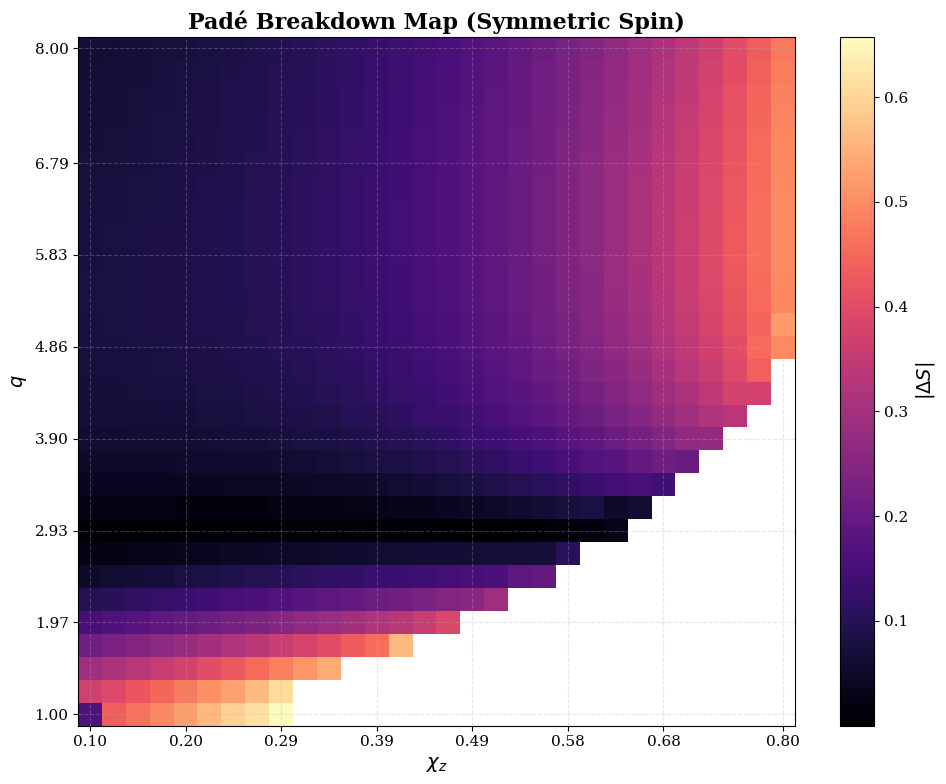

In [33]:
df_clean = df_results.dropna(subset=['Delta_S'])
df_clean['q_bin'] = df_clean['q'].round(2)
df_clean['chi_bin'] = df_clean['chi'].round(2)

heatmap_data = df_clean.pivot_table(index="q_bin", columns="chi_bin", values="Delta_S")

x_labels = heatmap_data.columns.values
y_labels = heatmap_data.index.values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap='magma', aspect='auto', origin='lower')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$|\Delta S|$', fontsize=14)

num_ticks = 8
x_idx = np.linspace(0, len(x_labels)-1, num_ticks, dtype=int)
y_idx = np.linspace(0, len(y_labels)-1, num_ticks, dtype=int)

ax.set_xticks(x_idx)
ax.set_yticks(y_idx)
ax.set_xticklabels([f"{x_labels[i]:.2f}" for i in x_idx])
ax.set_yticklabels([f"{y_labels[i]:.2f}" for i in y_idx])

plt.title('Padé Breakdown Map (Symmetric Spin)', fontsize=16, fontweight='bold')
plt.xlabel(r'$\chi_z$', fontsize=14)
plt.ylabel(r'$q$', fontsize=14)

plt.tight_layout()
plt.show()

Asymmetric Spin with Padè

In [34]:
def analyze_configuration_pade_asymmetric(q, chi1, chi2, a_array):
    
    result_fail = {
        "q": q, "chi1": chi1, "chi2": chi2, 
        "delta_chi": chi1 - chi2,
        "S_NR": np.nan, "S_Pade_max": np.nan, "Delta_S": np.nan
    }
    
    try:
    
        spin1 = [0.0, 0.0, chi1]
        spin2 = [0.0, 0.0, chi2]
        
        mf, chif_vec, *_ = sur_remnant_aligned.all(q, spin1, spin2)
            
        chi_f_nr = np.linalg.norm(chif_vec)
        
        Jf = chi_f_nr * (mf**2)
        S_final_nr = entropy(mf, Jf)

        if np.isnan(S_final_nr): return result_fail

        M_arr, J_arr, S_arr, _ = get_max_2PN(q, chi1, chi2, a_array)

        if S_arr is None or np.all(np.isnan(S_arr)):
             result_fail["S_NR"] = float(S_final_nr)
             return result_fail

        valid_mask = ~np.isnan(S_arr)
        x_data = 1.0 / np.sqrt(a_array[valid_mask])
        M_data = M_arr[valid_mask]
        J_data = J_arr[valid_mask]

        if len(x_data) < 4 or np.any(np.isnan(M_data)) or np.any(np.isnan(J_data)):
            result_fail["S_NR"] = float(S_final_nr) 
            return result_fail
        

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
            popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
            
  
        r_extrap = np.linspace(25.0, 1.5, 2000)
        x_extrap = 1.0 / np.sqrt(r_extrap)
            
        M_Pade = pade_2_1(x_extrap, *popt_M)
        J_Pade = pade_2_1(x_extrap, *popt_J)
        S_Pade = entropy(M_Pade, J_Pade)
        
        if np.all(np.isnan(S_Pade)):
            result_fail["S_NR"] = float(S_final_nr)
            return result_fail
            
        max_pade = np.nanmax(S_Pade)
            
        return {
            "q": q, 
            "chi1": chi1,
            "chi2": chi2,
            "delta_chi": chi1 - chi2,
            "S_NR": float(S_final_nr),
            "S_Pade_max": float(max_pade),
            "Delta_S": float(np.abs(max_pade - S_final_nr))
        }
        
    except Exception:
        result_fail["S_NR"] = float(S_final_nr) if 'S_final_nr' in locals() else np.nan
        return result_fail

In [35]:
results = []
spin_range = np.linspace(-0.8, 0.8, 15) 
q_range = np.linspace(1, 8, 15)
a_3 = np.linspace(100.0, 7.0, 1000)

for q in q_range:
    for chi1 in spin_range:
        for chi2 in spin_range:
            if abs(chi1) > 0.8 or abs(chi2) > 0.8: continue
            
            res = analyze_configuration_pade_asymmetric(q, chi1, chi2, a_3)
            results.append(res)

df_asym = pd.DataFrame(results)

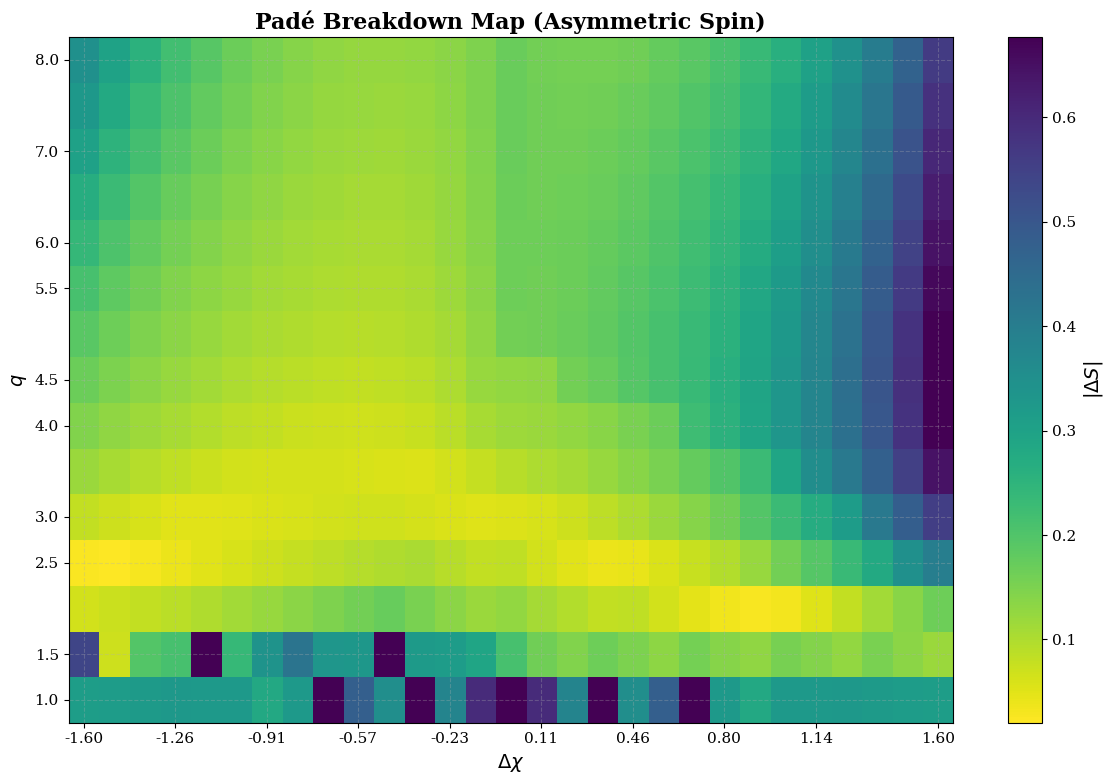

In [36]:
df_clean = df_asym.dropna(subset=['Delta_S'])

df_clean['q_bin'] = df_clean['q'].round(1)
df_clean['delta_chi_bin'] = df_clean['delta_chi'].round(2)

heatmap_data = df_clean.pivot_table(index="q_bin", columns="delta_chi_bin", values="Delta_S")

x_labels = heatmap_data.columns.values
y_labels = heatmap_data.index.values

valori_validi = heatmap_data.values[~np.isnan(heatmap_data.values)]
limite_vmax = np.percentile(valori_validi, 98) 

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(heatmap_data.values, cmap='viridis_r', aspect='auto', origin='lower', vmax=limite_vmax)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$|\Delta S|$', fontsize=14)

num_x_ticks = min(10, len(x_labels))
num_y_ticks = min(10, len(y_labels))

x_idx = np.linspace(0, len(x_labels)-1, num_x_ticks, dtype=int)
y_idx = np.linspace(0, len(y_labels)-1, num_y_ticks, dtype=int)

ax.set_xticks(x_idx)
ax.set_yticks(y_idx)
ax.set_xticklabels([f"{x_labels[i]:.2f}" for i in x_idx])
ax.set_yticklabels([f"{y_labels[i]:.1f}" for i in y_idx])

plt.title('Padé Breakdown Map (Asymmetric Spin)', fontsize=16, fontweight='bold')
plt.xlabel(r'$\Delta \chi$', fontsize=14)
plt.ylabel(r'$q$', fontsize=14)

plt.tight_layout()
plt.show()

**DELTA a ANALYSIS**

In [37]:
q_a = 3
chi1_a = 0.5
chi2_a = 0.5

a_a = np.linspace(100.0, 7.0, 10000) 

spin1 = [0.0, 0.0, chi1_a]
spin2 = [0.0, 0.0, chi2_a]

In [ ]:
# SURROGATE
risultato = simulate_conjecture_2PN(q_a, chi1_a, chi2_a)
S_plot = risultato['S_Kerr']
t_array, r_array = risultato['t'], risultato['r']


idx_merger_raw = np.argmin(np.abs(t_array))
r_merger_NR = r_array[idx_merger_raw]


dr = np.diff(r_array)
rimbalzi = np.where(dr[idx_merger_raw:] > 0)[0]
idx_end = idx_merger_raw + rimbalzi[0] if len(rimbalzi) > 0 else len(r_array) - 1
r_clean, S_clean, t_clean = r_array[:idx_end], S_plot[:idx_end], t_array[:idx_end]


idx_peak_surr = np.nanargmax(S_clean)
r_peak_surr = r_clean[idx_peak_surr]
delta_r_surr = np.abs(r_merger_NR - r_peak_surr)
S_peak_surr = S_clean[idx_peak_surr]


r_extrap = np.linspace(25.0, 1.2, 3000)
x_extrap = 1.0 / np.sqrt(r_extrap)
M_arr, J_arr, S_arr, _ = get_max_2PN(q_a, chi1_a, chi2_a, a_a)
valid_mask = ~np.isnan(S_arr)
x_data = 1.0 / np.sqrt(a_a[valid_mask])
M_data, J_data = M_arr[valid_mask], J_arr[valid_mask]

# PADÉ
popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
S_Pade_extrap = entropy(pade_2_1(x_extrap, *popt_M), pade_2_1(x_extrap, *popt_J))
idx_max_S_Pade = np.nanargmax(S_Pade_extrap)
S_max_Pade = S_Pade_extrap[idx_max_S_Pade]
r_merger_Pade = r_extrap[idx_max_S_Pade]
delta_r_Pade = np.abs(r_merger_NR - r_merger_Pade)

# TAYLOR 
poly_M = np.polyfit(x_data, M_data, 4)
poly_J = np.polyfit(x_data, J_data, 4)
S_Taylor_extrap = entropy(np.polyval(poly_M, x_extrap), np.polyval(poly_J, x_extrap))
idx_max_S_Taylor = np.nanargmax(S_Taylor_extrap)
S_max_Taylor = S_Taylor_extrap[idx_max_S_Taylor]
r_merger_Taylor = r_extrap[idx_max_S_Taylor]
delta_r_Taylor = np.abs(r_merger_NR - r_merger_Taylor)


print(f"NR separation at merger       = {r_merger_NR:.4f} M")
print("-" * 50)
print(f"Surrogate Peak at r           = {r_peak_surr:.4f} M")
print(f"Surrogate Delta r             = {delta_r_surr:.4f} M")
print("-" * 50)
print(f"Taylor Peak at r              = {r_merger_Taylor:.4f} M")
print(f"Taylor Delta r                = {delta_r_Taylor:.4f} M")
print("-" * 50)
print(f"Padé Peak at r                = {r_merger_Pade:.4f} M")
print(f"Padé Delta r                  = {delta_r_Pade:.4f} M")

NR separation at merger       = 2.9738 M
--------------------------------------------------
Surrogate Peak at r           = 2.5614 M
Surrogate Delta r             = 0.4123 M
--------------------------------------------------
Taylor Peak at r              = 3.9458 M
Taylor Delta r                = 0.9721 M
--------------------------------------------------
Padé Peak at r                = 2.9380 M
Padé Delta r                  = 0.0358 M


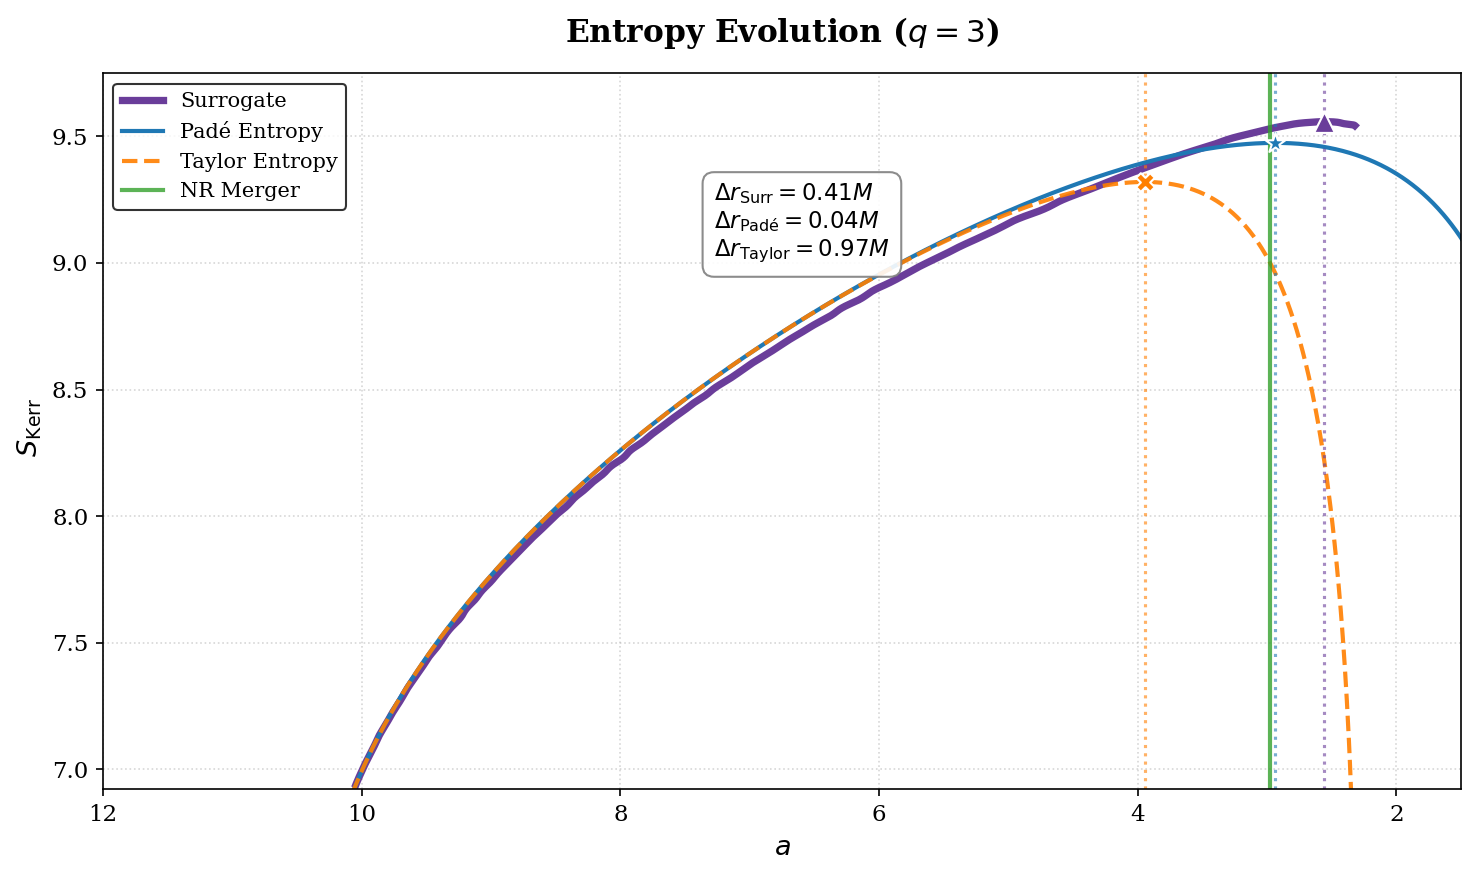

In [40]:
plt.figure(figsize=(10, 6), dpi=150)

plt.plot(r_clean, S_clean, lw=3.5, color='#6a3d9a', label='Surrogate', zorder=2)
plt.plot(r_extrap, S_Pade_extrap, lw=2.0, color='#1f78b4', label='Padé Entropy', zorder=2)
plt.plot(r_extrap, S_Taylor_extrap, lw=2.0, color='#ff7f00', linestyle='--', alpha=0.9, label='Taylor Entropy', zorder=2)

plt.axvline(r_peak_surr, color='#6a3d9a', linestyle=':', alpha=0.6, lw=1.5)
plt.axvline(r_merger_Pade, color='#1f78b4', linestyle=':', alpha=0.6, lw=1.5)
plt.axvline(r_merger_Taylor, color='#ff7f00', linestyle=':', alpha=0.6, lw=1.5)

plt.axvline(r_merger_NR, color='#33a02c', linestyle='-', lw=2, alpha=0.8, label='NR Merger')

plt.scatter(r_peak_surr, S_peak_surr, color='#6a3d9a', s=100, zorder=3, marker='^', edgecolors='white')
plt.scatter(r_merger_Pade, S_max_Pade, color='#1f78b4', s=100, zorder=3, marker='*', edgecolors='white')
plt.scatter(r_merger_Taylor, S_max_Taylor, color='#ff7f00', s=80, zorder=3, marker='X', edgecolors='white')

box_text = (r"$\Delta r_{\text{Surr}} = " + f"{delta_r_surr:.2f}M$" + "\n" +
            r"$\Delta r_{\text{Padé}} = " + f"{delta_r_Pade:.2f}M$" + "\n" +
            r"$\Delta r_{\text{Taylor}} = " + f"{delta_r_Taylor:.2f}M$")
plt.text(0.45, 0.85, box_text, transform=plt.gca().transAxes, 
         fontsize=11, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9),
         ha='left', va='top')

plt.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=10)
plt.gca().invert_xaxis()
plt.xlim(12.0, 1.5)
plt.ylim(np.min(S_clean[r_clean <= 10.0]) * 0.99, max(S_max_Pade, S_max_Taylor, S_peak_surr) * 1.02)

plt.xlabel(r'$a$', fontsize=13)
plt.ylabel(r' $S_{\mathrm{Kerr}}$', fontsize=13)
plt.title(rf'Entropy Evolution ($q={q_a}$)', fontsize=15, fontweight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

SPIN CONFIGURATIONS HEATMAP

Padè

In [211]:
q_padè = 4
a_padè = np.linspace(30.0, 5.0, 10000) 

n_points_p = 10
chi_range_p = np.linspace(-0.8, 0.8, n_points_p)  
chi1_grid_p, chi2_grid_p = np.meshgrid(chi_range_p, chi_range_p)
delta_r_matrix = np.full_like(chi1_grid_p, np.nan)

In [186]:
# Single Heatmap

total_iterations = n_points_p * n_points_p
pbar = tqdm(total=total_iterations, desc="Computing Parameter Space")

for i in range(n_points_p):
    for j in range(n_points_p):
        chi1_val = chi1_grid_p[i, j]
        chi2_val = chi2_grid_p[i, j]
        
        try:

            spin1 = [0.0, 0.0, chi1_val]
            spin2 = [0.0, 0.0, chi2_val]

            # surrogate
            t, h, _ = sur_wave_aligned(q_padè, spin1, spin2, dt=0.1, f_low=0.01)
            omega = np.abs(np.gradient(np.unwrap(np.angle(h[(2,2)])), t)) / 2.0
            r_sep_nr = (np.maximum(omega, 1e-8))**(-2/3)
            r_merger_nr = r_sep_nr[np.argmin(np.abs(t))]
            
            # PADÉ
            M_arr, J_arr, S_arr, _ = get_max_2PN(q_padè, chi1_val, chi2_val, a_padè)
            valid = ~np.isnan(S_arr)
            x_data = 1.0 / np.sqrt(a_padè[valid])
            M_data, J_data = M_arr[valid], J_arr[valid]
            popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
            popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
            r_extrap = np.linspace(25.0, 1.0, 2000)
            x_extrap = 1.0 / np.sqrt(r_extrap)
            S_Pade = entropy(pade_2_1(x_extrap, *popt_M), pade_2_1(x_extrap, *popt_J))
            r_peak_pade = r_extrap[np.nanargmax(S_Pade)]
            
            
            delta_r_matrix[i, j] = np.abs(r_merger_nr - r_peak_pade)
            
        except Exception as e:
            
            pass
        
        finally:
            pbar.update(1) 

pbar.close()

Computing Parameter Space:   0%|          | 0/100 [00:00<?, ?it/s]

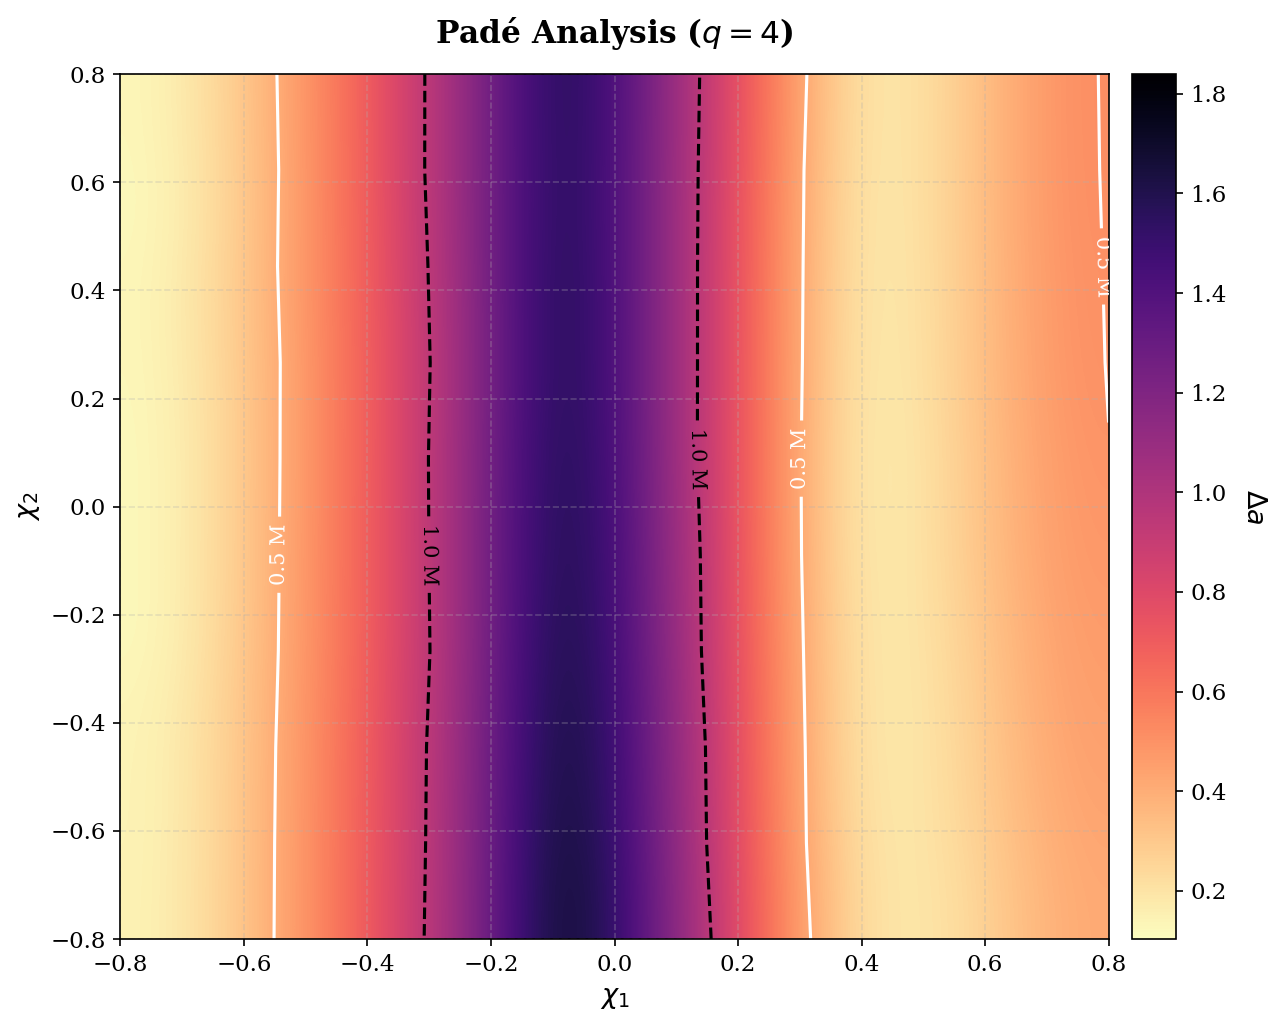

In [187]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
})
plt.figure(figsize=(9, 7), dpi=150)

heatmap = plt.imshow(delta_r_matrix, origin='lower', 
                     extent=[chi_range_p.min(), chi_range_p.max(), chi_range_p.min(), chi_range_p.max()], 
                     cmap='magma_r', aspect='auto', interpolation='bicubic')
cbar = plt.colorbar(heatmap, pad=0.02)
cbar.set_label(r'$\Delta a$', rotation=270, labelpad=20)
contours = plt.contour(chi1_grid_p, chi2_grid_p, delta_r_matrix, levels=[0.5, 1.0], 
                       colors=['white', 'black'], linestyles=['-', '--'], linewidths=1.5)
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f M')
plt.xlabel(r'$\chi_1$')
plt.ylabel(r'$\chi_2$')
plt.title(rf'Padé Analysis ($q={q_padè}$)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [221]:
# Multiple Heatmaps

q_values = [1.5, 2.0, 3.0, 4.0] 
results_dict = {}
total_iterations = len(q_values) * n_points_p * n_points_p
pbar = tqdm(total=total_iterations, desc="Multi-q Computation in progress")

for q_val in q_values:
    current_matrix = np.full_like(chi1_grid_p, np.nan)
    
    for i in range(n_points_p):
        for j in range(n_points_p):
            chi1_val = chi1_grid_p[i, j]
            chi2_val = chi2_grid_p[i, j]
            
            try:
                # Surrogate
                spin1 = [0.0, 0.0, chi1_val]
                spin2 = [0.0, 0.0, chi2_val]
                t, h, _ = sur_wave_aligned(q_val, spin1, spin2, dt=0.2, f_low=0.01)
                omega = np.abs(np.gradient(np.unwrap(np.angle(h[(2,2)])), t)) / 2.0
                r_sep_nr = (np.maximum(omega, 1e-8))**(-2/3)
                r_merger_nr = r_sep_nr[np.argmin(np.abs(t))]

                # Padè
                M_arr, J_arr, S_arr, _ = get_max_2PN(q_val, chi1_val, chi2_val, a_padè)
                valid = ~np.isnan(S_arr)
                x_data = 1.0 / np.sqrt(a_padè[valid])
                M_data, J_data = M_arr[valid], J_arr[valid]
                popt_M, _ = curve_fit(pade_2_1, x_data, M_data, p0=[1,1,1,0.1], maxfev=5000)
                popt_J, _ = curve_fit(pade_2_1, x_data, J_data, p0=[1,1,1,0.1], maxfev=5000)
                r_extrap = np.linspace(25.0, 1.0, 10000)
                x_extrap = 1.0 / np.sqrt(r_extrap)
                S_Pade = entropy(pade_2_1(x_extrap, *popt_M), pade_2_1(x_extrap, *popt_J))
                r_peak_pade = r_extrap[np.nanargmax(S_Pade)]
                
                current_matrix[i, j] = np.abs(r_merger_nr - r_peak_pade)
                
            except Exception:
                pass
                
            finally:
                pbar.update(1)
                
    results_dict[q_val] = current_matrix

pbar.close()

Multi-q Computation in progress:   0%|          | 0/400 [00:00<?, ?it/s]

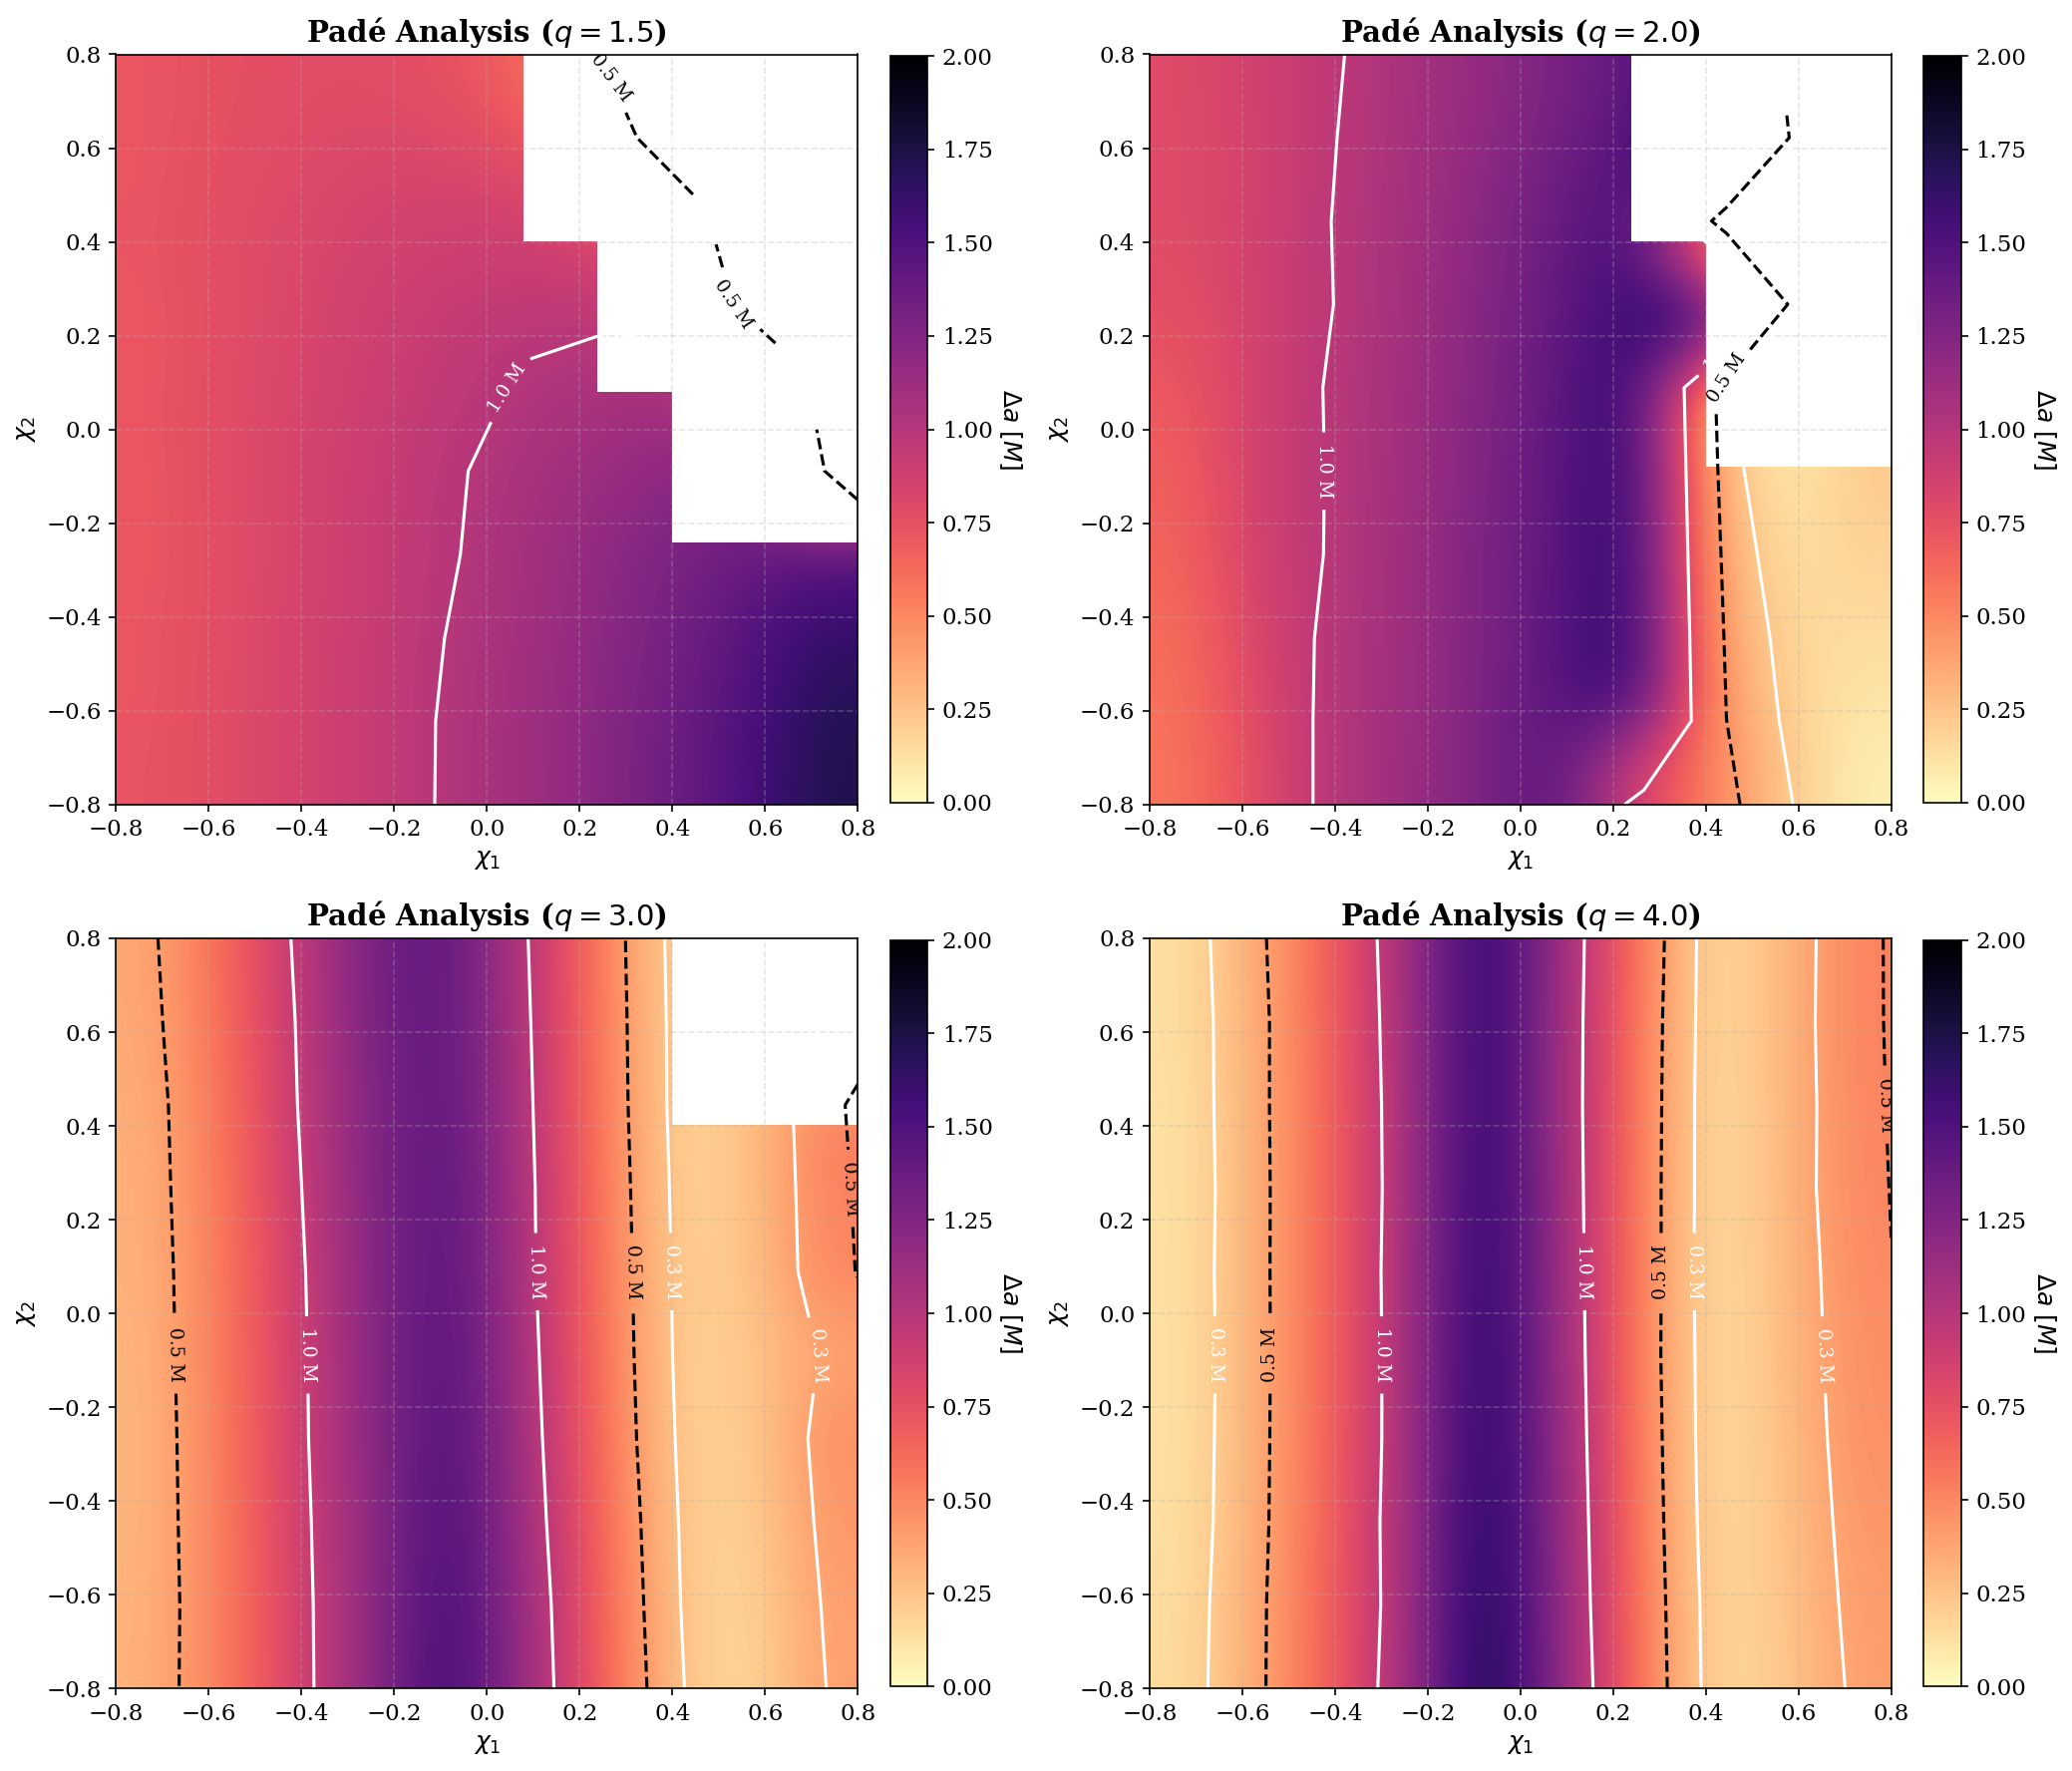

In [222]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12), dpi=150)
axes = axes.flatten()

for idx, q_val in enumerate(q_values):
    ax = axes[idx]
    matrix = results_dict[q_val]
    masked_matrix = np.ma.masked_invalid(matrix)
    im = ax.imshow(matrix, origin='lower', 
                   extent=[chi_range_p.min(), chi_range_p.max(), chi_range_p.min(), chi_range_p.max()], 
                   cmap='magma_r', aspect='auto', interpolation='bicubic',vmin=0.0, vmax=2.0)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\Delta a \ [M]$', rotation=270, labelpad=15)
    contours = ax.contour(chi1_grid_p, chi2_grid_p, masked_matrix, levels=[0.3, 0.5, 1.0], 
                          colors=['white', 'black'], linestyles=['-', '--'], linewidths=1.5)
    ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f M')
    ax.set_xlabel(r'$\chi_1$')
    ax.set_ylabel(r'$\chi_2$')
    ax.set_title(rf'Padé Analysis ($q={q_val}$)', fontweight='bold')

plt.tight_layout()
plt.show()

Taylor

In [204]:
q_taylor = 4.0 
a_taylor = np.linspace(30.0, 5.0, 10000)

n_points_t = 30
chi_range_t = np.linspace(-0.8, 0.8, n_points_t)  
chi1_grid_t, chi2_grid_t = np.meshgrid(chi_range_t, chi_range_t)
delta_r_matrix_taylor = np.full_like(chi1_grid_t, np.nan)

In [205]:
# Single Heatmap

total_iterations = n_points_t * n_points_t
pbar = tqdm(total=total_iterations, desc="Computing Taylor Parameter Space")

for i in range(n_points_t):
    for j in range(n_points_t):
        chi1_val = chi1_grid_t[i, j]
        chi2_val = chi2_grid_t[i, j]
        
        try:
            # Surrogate
            spin1 = [0.0, 0.0, chi1_val]
            spin2 = [0.0, 0.0, chi2_val]
            t, h, _ = sur_wave_aligned(q_taylor, spin1, spin2, dt=0.2, f_low=0.01)
            omega = np.abs(np.gradient(np.unwrap(np.angle(h[(2,2)])), t)) / 2.0
            r_sep_nr = (np.maximum(omega, 1e-8))**(-2/3)
            r_merger_nr = r_sep_nr[np.argmin(np.abs(t))]
            
            # Taylor
            M_arr, J_arr, S_arr, _ = get_max_2PN(q_taylor, chi1_val, chi2_val, a_taylor)
            valid = ~np.isnan(S_arr)
            x_data = 1.0 / np.sqrt(a_taylor[valid])
            M_data, J_data = M_arr[valid], J_arr[valid]
            poly_M = np.polyfit(x_data, M_data, 3)
            poly_J = np.polyfit(x_data, J_data, 3)
            r_extrap = np.linspace(25.0, 1.0, 1000)
            x_extrap = 1.0 / np.sqrt(r_extrap)
            M_Taylor = np.polyval(poly_M, x_extrap)
            J_Taylor = np.polyval(poly_J, x_extrap)
            S_Taylor = entropy(M_Taylor, J_Taylor)
            r_peak_taylor = r_extrap[np.nanargmax(S_Taylor)]
            
            delta_r_matrix_taylor[i, j] = np.abs(r_merger_nr - r_peak_taylor)
            
        except Exception as e:
            pass
        
        finally:
            pbar.update(1)

pbar.close()

Computing Taylor Parameter Space:   0%|          | 0/900 [00:00<?, ?it/s]

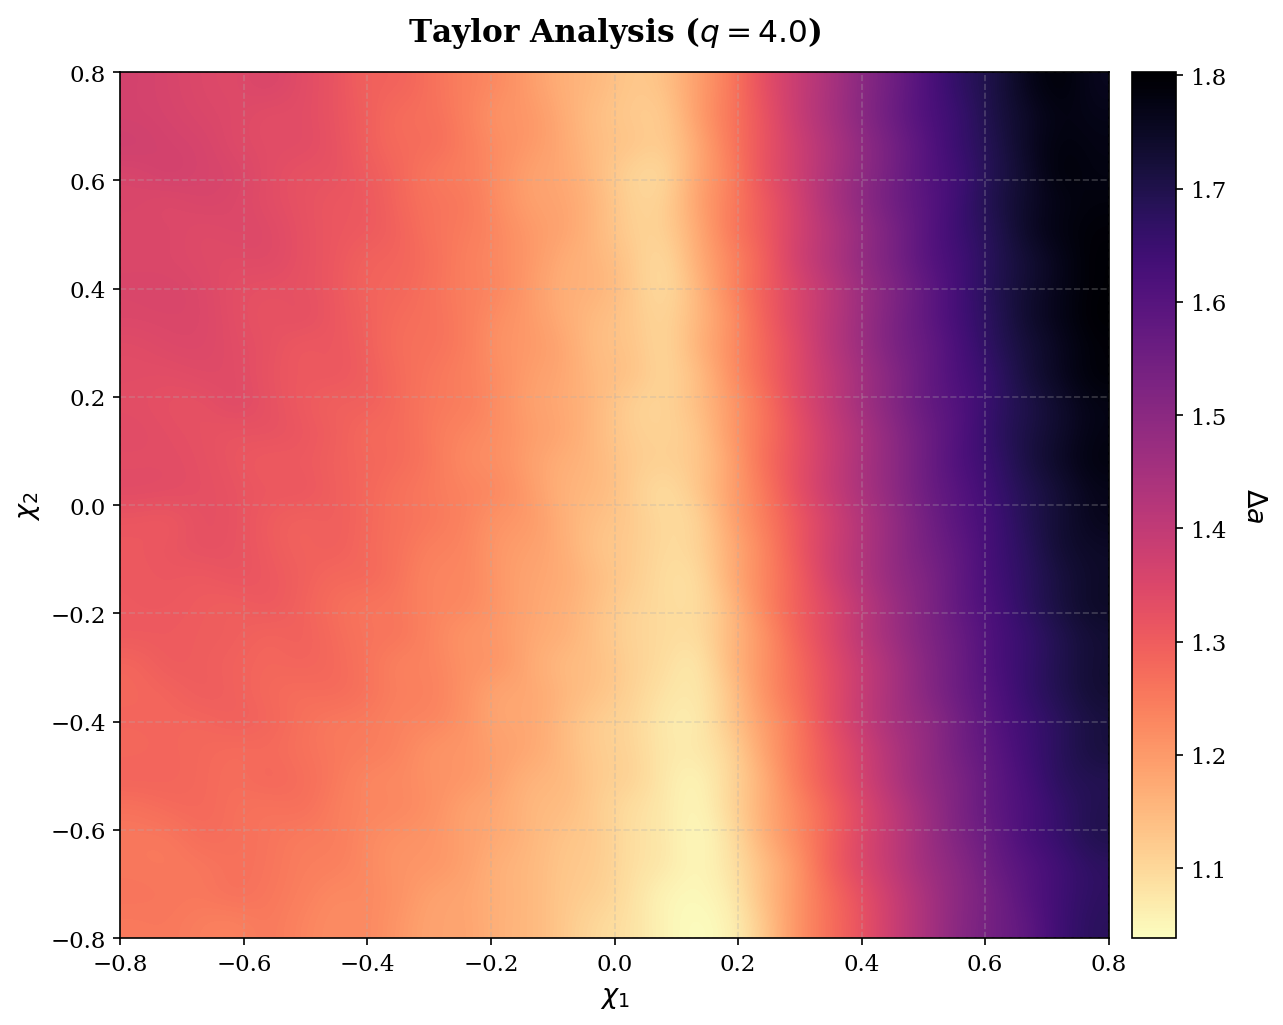

In [206]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
})
plt.figure(figsize=(9, 7), dpi=150)
masked_matrix = np.ma.masked_invalid(matrix)
heatmap = plt.imshow(delta_r_matrix_taylor, origin='lower', 
                     extent=[chi_range_t.min(), chi_range_t.max(), chi_range_t.min(), chi_range_t.max()], 
                     cmap='magma_r', aspect='auto', interpolation='bicubic')
cbar = plt.colorbar(heatmap, pad=0.02)
cbar.set_label(r'$\Delta a$', rotation=270, labelpad=20)
contours = plt.contour(chi1_grid_t, chi2_grid_t, delta_r_matrix_taylor, levels=[0.5, 1.0], 
                       colors=['white', 'black'], linestyles=['-', '--'], linewidths=1.5)
plt.clabel(contours, inline=True, fontsize=10, fmt='%.1f M')
plt.xlabel(r'$\chi_1$')
plt.ylabel(r'$\chi_2$')
plt.title(rf'Taylor Analysis ($q={q_taylor}$)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [207]:
# Multiple Heatmaps

q_values = [1.5, 2.0, 3.0, 4.0] 
results_dict_taylor = {}
total_iterations = len(q_values) * n_points_t * n_points_t
pbar = tqdm(total=total_iterations, desc="Multi-q Taylor Computation in progress")

for q_val in q_values:
    current_matrix_taylor = np.full_like(chi1_grid_t, np.nan)
    
    for i in range(n_points_t):
        for j in range(n_points_t):
            chi1_val = chi1_grid_t[i, j]
            chi2_val = chi2_grid_t[i, j]
            
            try:
                # Surrogate
                spin1 = [0.0, 0.0, chi1_val]
                spin2 = [0.0, 0.0, chi2_val]
                t, h, _ = sur_wave_aligned(q_val, spin1, spin2, dt=0.1, f_low=0.01)
                omega = np.abs(np.gradient(np.unwrap(np.angle(h[(2,2)])), t)) / 2.0
                r_sep_nr = (np.maximum(omega, 1e-8))**(-2/3)
                r_merger_nr = r_sep_nr[np.argmin(np.abs(t))]
                
                # Taylor
                M_arr, J_arr, S_arr, _ = get_max_2PN(q_val, chi1_val, chi2_val, a_padè)
                valid = ~np.isnan(S_arr)
                x_data = 1.0 / np.sqrt(a_taylor[valid])
                M_data, J_data = M_arr[valid], J_arr[valid]
                poly_M = np.polyfit(x_data, M_data, 3)
                poly_J = np.polyfit(x_data, J_data, 3)
                r_extrap = np.linspace(25.0, 1.0, 1000)
                x_extrap = 1.0 / np.sqrt(r_extrap)
                M_Taylor = np.polyval(poly_M, x_extrap)
                J_Taylor = np.polyval(poly_J, x_extrap)
                S_Taylor = entropy(M_Taylor, J_Taylor)
                r_peak_taylor = r_extrap[np.nanargmax(S_Taylor)]
                
                current_matrix_taylor[i, j] = np.abs(r_merger_nr - r_peak_taylor)
                
            except Exception:
                pass
                
            finally:
                pbar.update(1)
                
    results_dict_taylor[q_val] = current_matrix_taylor

Multi-q Taylor Computation in progress:   0%|          | 0/3600 [00:00<?, ?it/s]

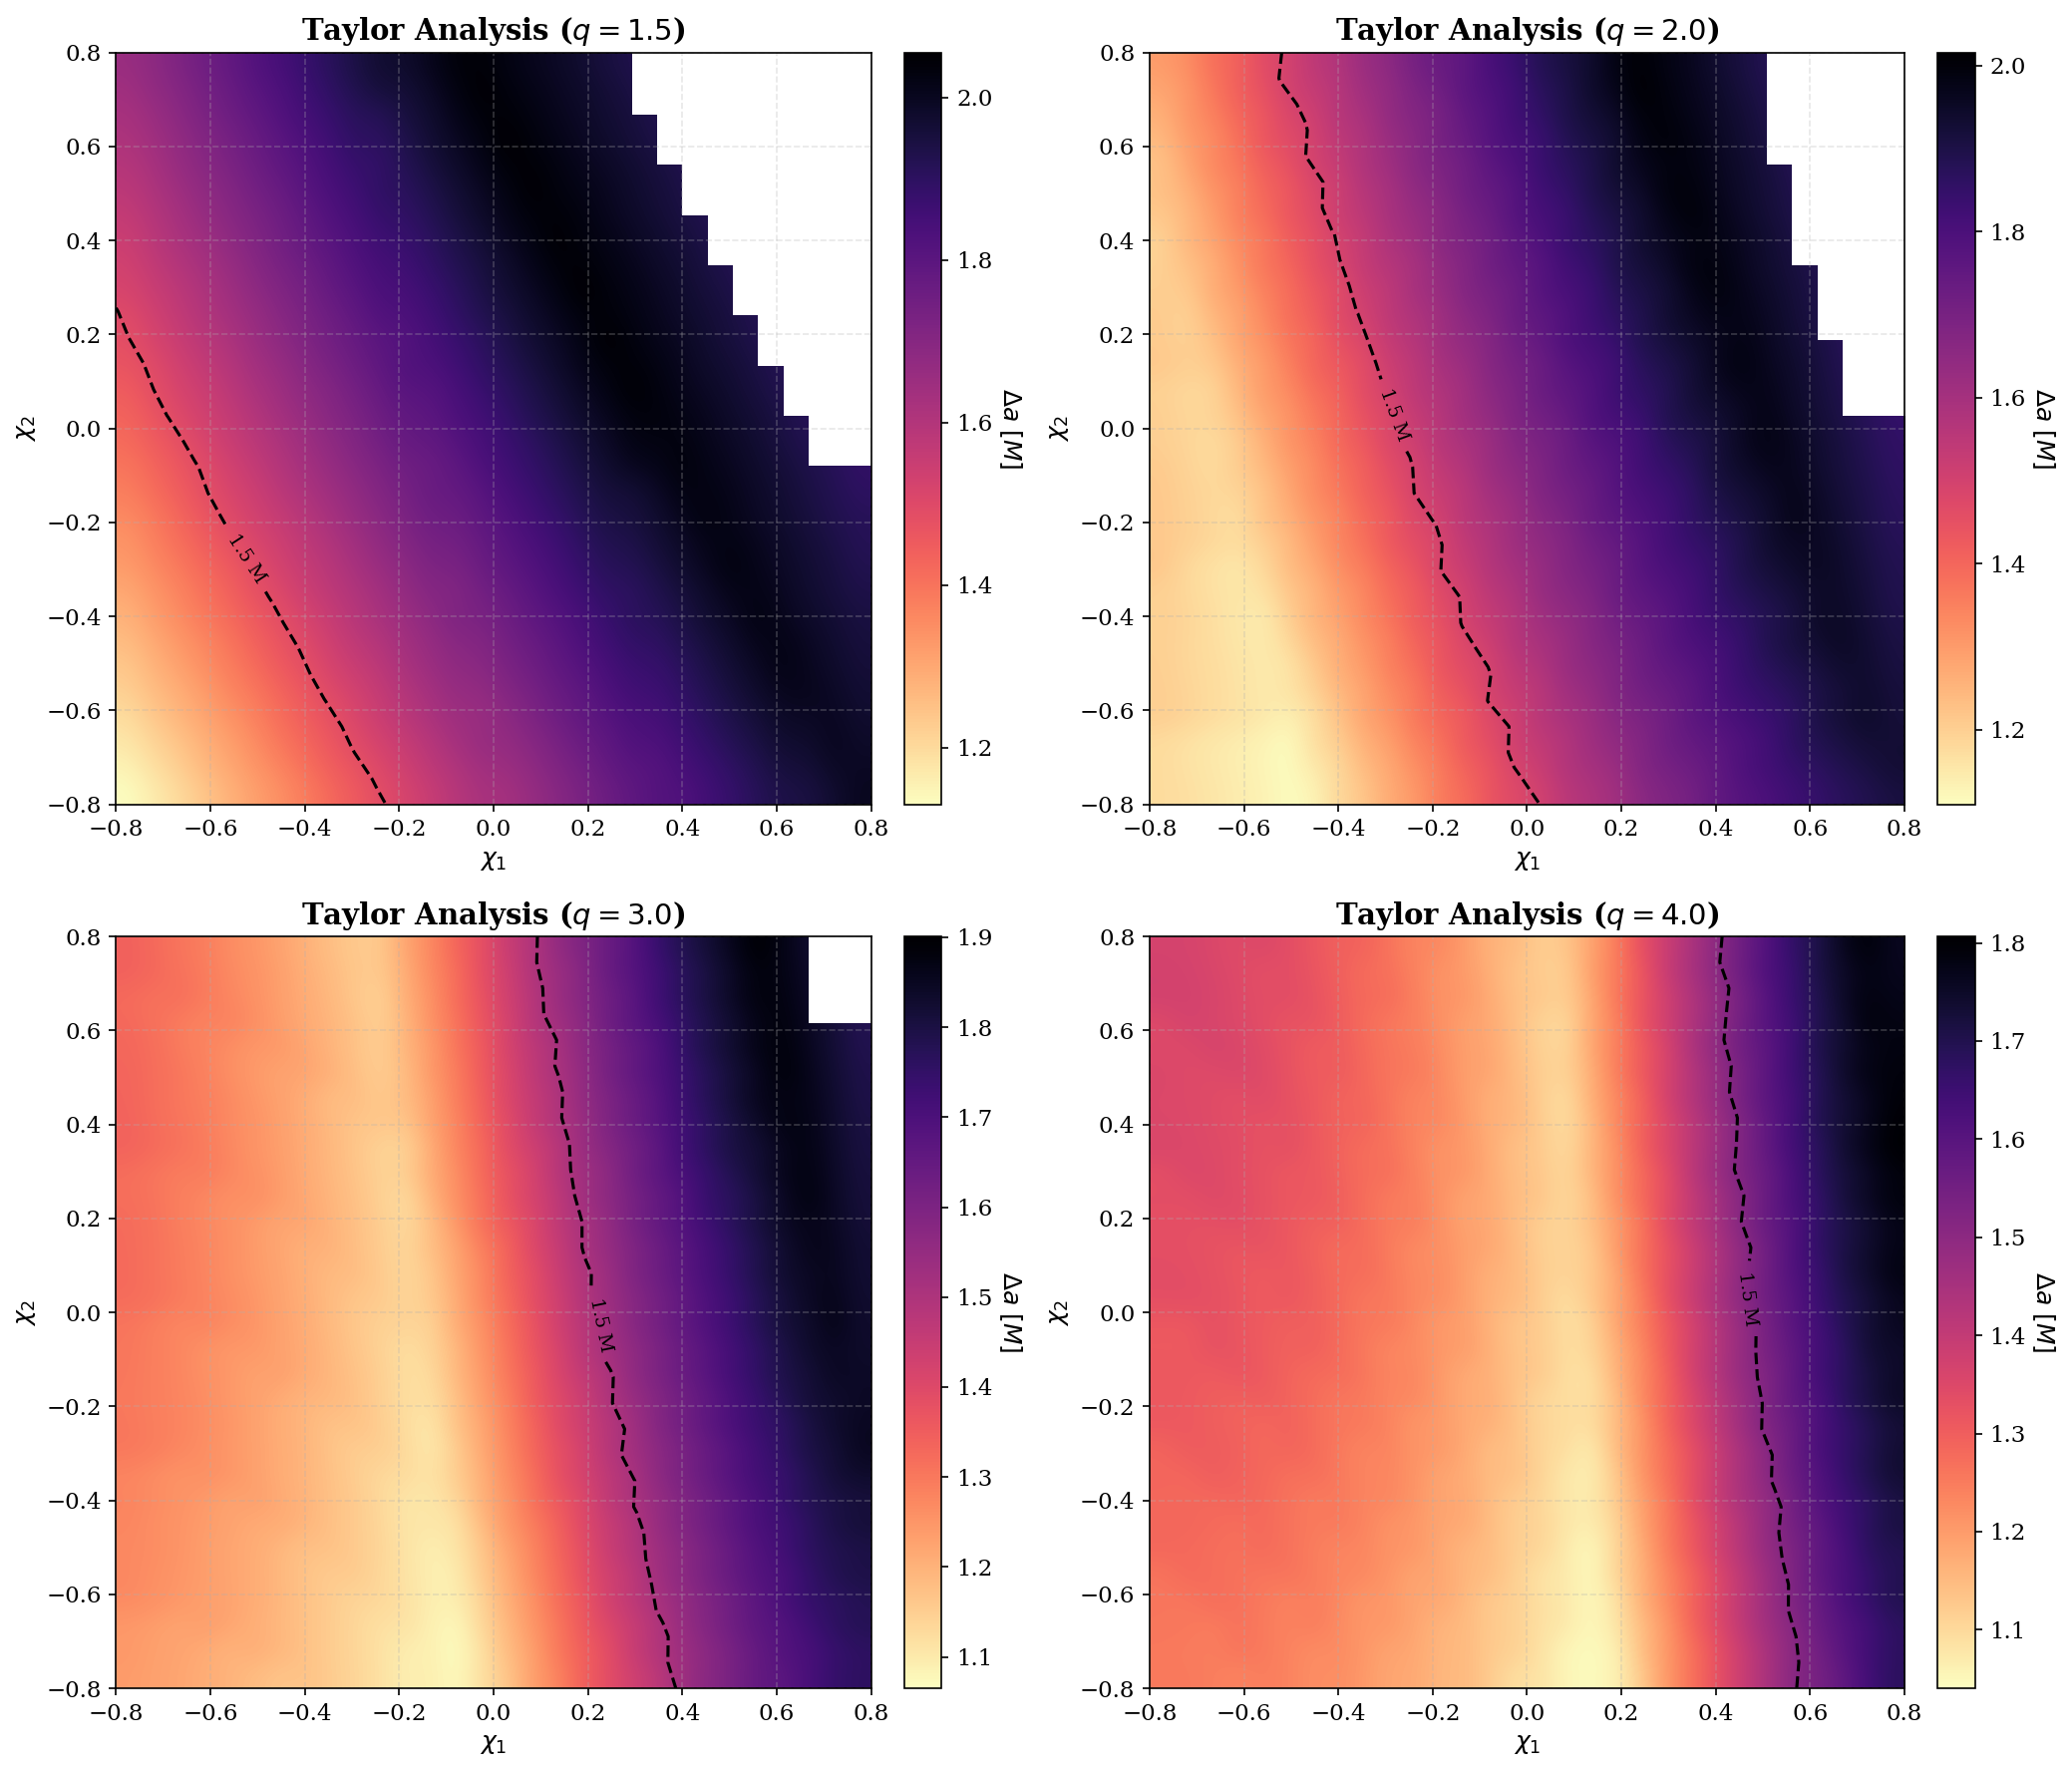

In [208]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12), dpi=150)
axes = axes.flatten()

for idx, q_val in enumerate(q_values):
    ax = axes[idx]
    matrix = results_dict_taylor[q_val]
    im = ax.imshow(matrix, origin='lower', 
                   extent=[chi_range_t.min(), chi_range_t.max(), chi_range_t.min(), chi_range_t.max()], 
                   cmap='magma_r', aspect='auto', interpolation='bicubic')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\Delta a \ [M]$', rotation=270, labelpad=15)
    contours = ax.contour(chi1_grid_t, chi2_grid_t, matrix, levels=[1.0, 1.5], 
                          colors=['white', 'black'], linestyles=['-', '--'], linewidths=1.5)
    ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f M')
    ax.set_xlabel(r'$\chi_1$')
    ax.set_ylabel(r'$\chi_2$')
    ax.set_title(rf'Taylor Analysis ($q={q_val}$)', fontweight='bold')

plt.tight_layout()
plt.show()

NR

In [200]:
q_NR = 4.0 
a_NR = np.linspace(30.0, 5.0, 10000)

n_points_NR = 30
chi_range_NR = np.linspace(-0.8, 0.8, n_points_NR)  
chi1_grid_NR, chi2_grid_NR = np.meshgrid(chi_range_NR, chi_range_NR)
delta_r_matrix_NR = np.full_like(chi1_grid_NR, np.nan)

In [201]:
# Multiple Heatmaps

q_values = [1.5, 2.0, 3.0, 4.0] 
results_dict_surrogate = {}

total_iterations = len(q_values) * n_points_NR * n_points_NR
pbar = tqdm(total=total_iterations, desc="Multi-q Surrogate Computation")

for q_val in q_values:

    current_matrix_surr = np.full_like(chi1_grid_NR, np.nan)
    
    for i in range(n_points_NR):
        for j in range(n_points_NR):
            chi1_val = chi1_grid_NR[i, j]
            chi2_val = chi2_grid_NR[i, j]
            
            try:
                
                risultato = simulate_conjecture_2PN(q_val, chi1_val, chi2_val)
                S_plot = risultato['S_Kerr']
                t_array, r_array = risultato['t'], risultato['r']
                
                idx_merger_raw = np.argmin(np.abs(t_array))
                r_merger_NR = r_array[idx_merger_raw]
                
                dr = np.diff(r_array)
                rimbalzi = np.where(dr[idx_merger_raw:] > 0)[0]
                idx_end = idx_merger_raw + rimbalzi[0] if len(rimbalzi) > 0 else len(r_array) - 1
                
                r_clean = r_array[:idx_end]
                S_clean = S_plot[:idx_end]
                
                idx_peak_surr = np.nanargmax(S_clean)
                r_peak_surr = r_clean[idx_peak_surr]
                

                current_matrix_surr[i, j] = np.abs(r_merger_NR - r_peak_surr)
                
            except Exception:
                pass
                
            finally:
                pbar.update(1)
                
    results_dict_surrogate[q_val] = current_matrix_surr

pbar.close()

Multi-q Surrogate Computation:   0%|          | 0/3600 [00:00<?, ?it/s]

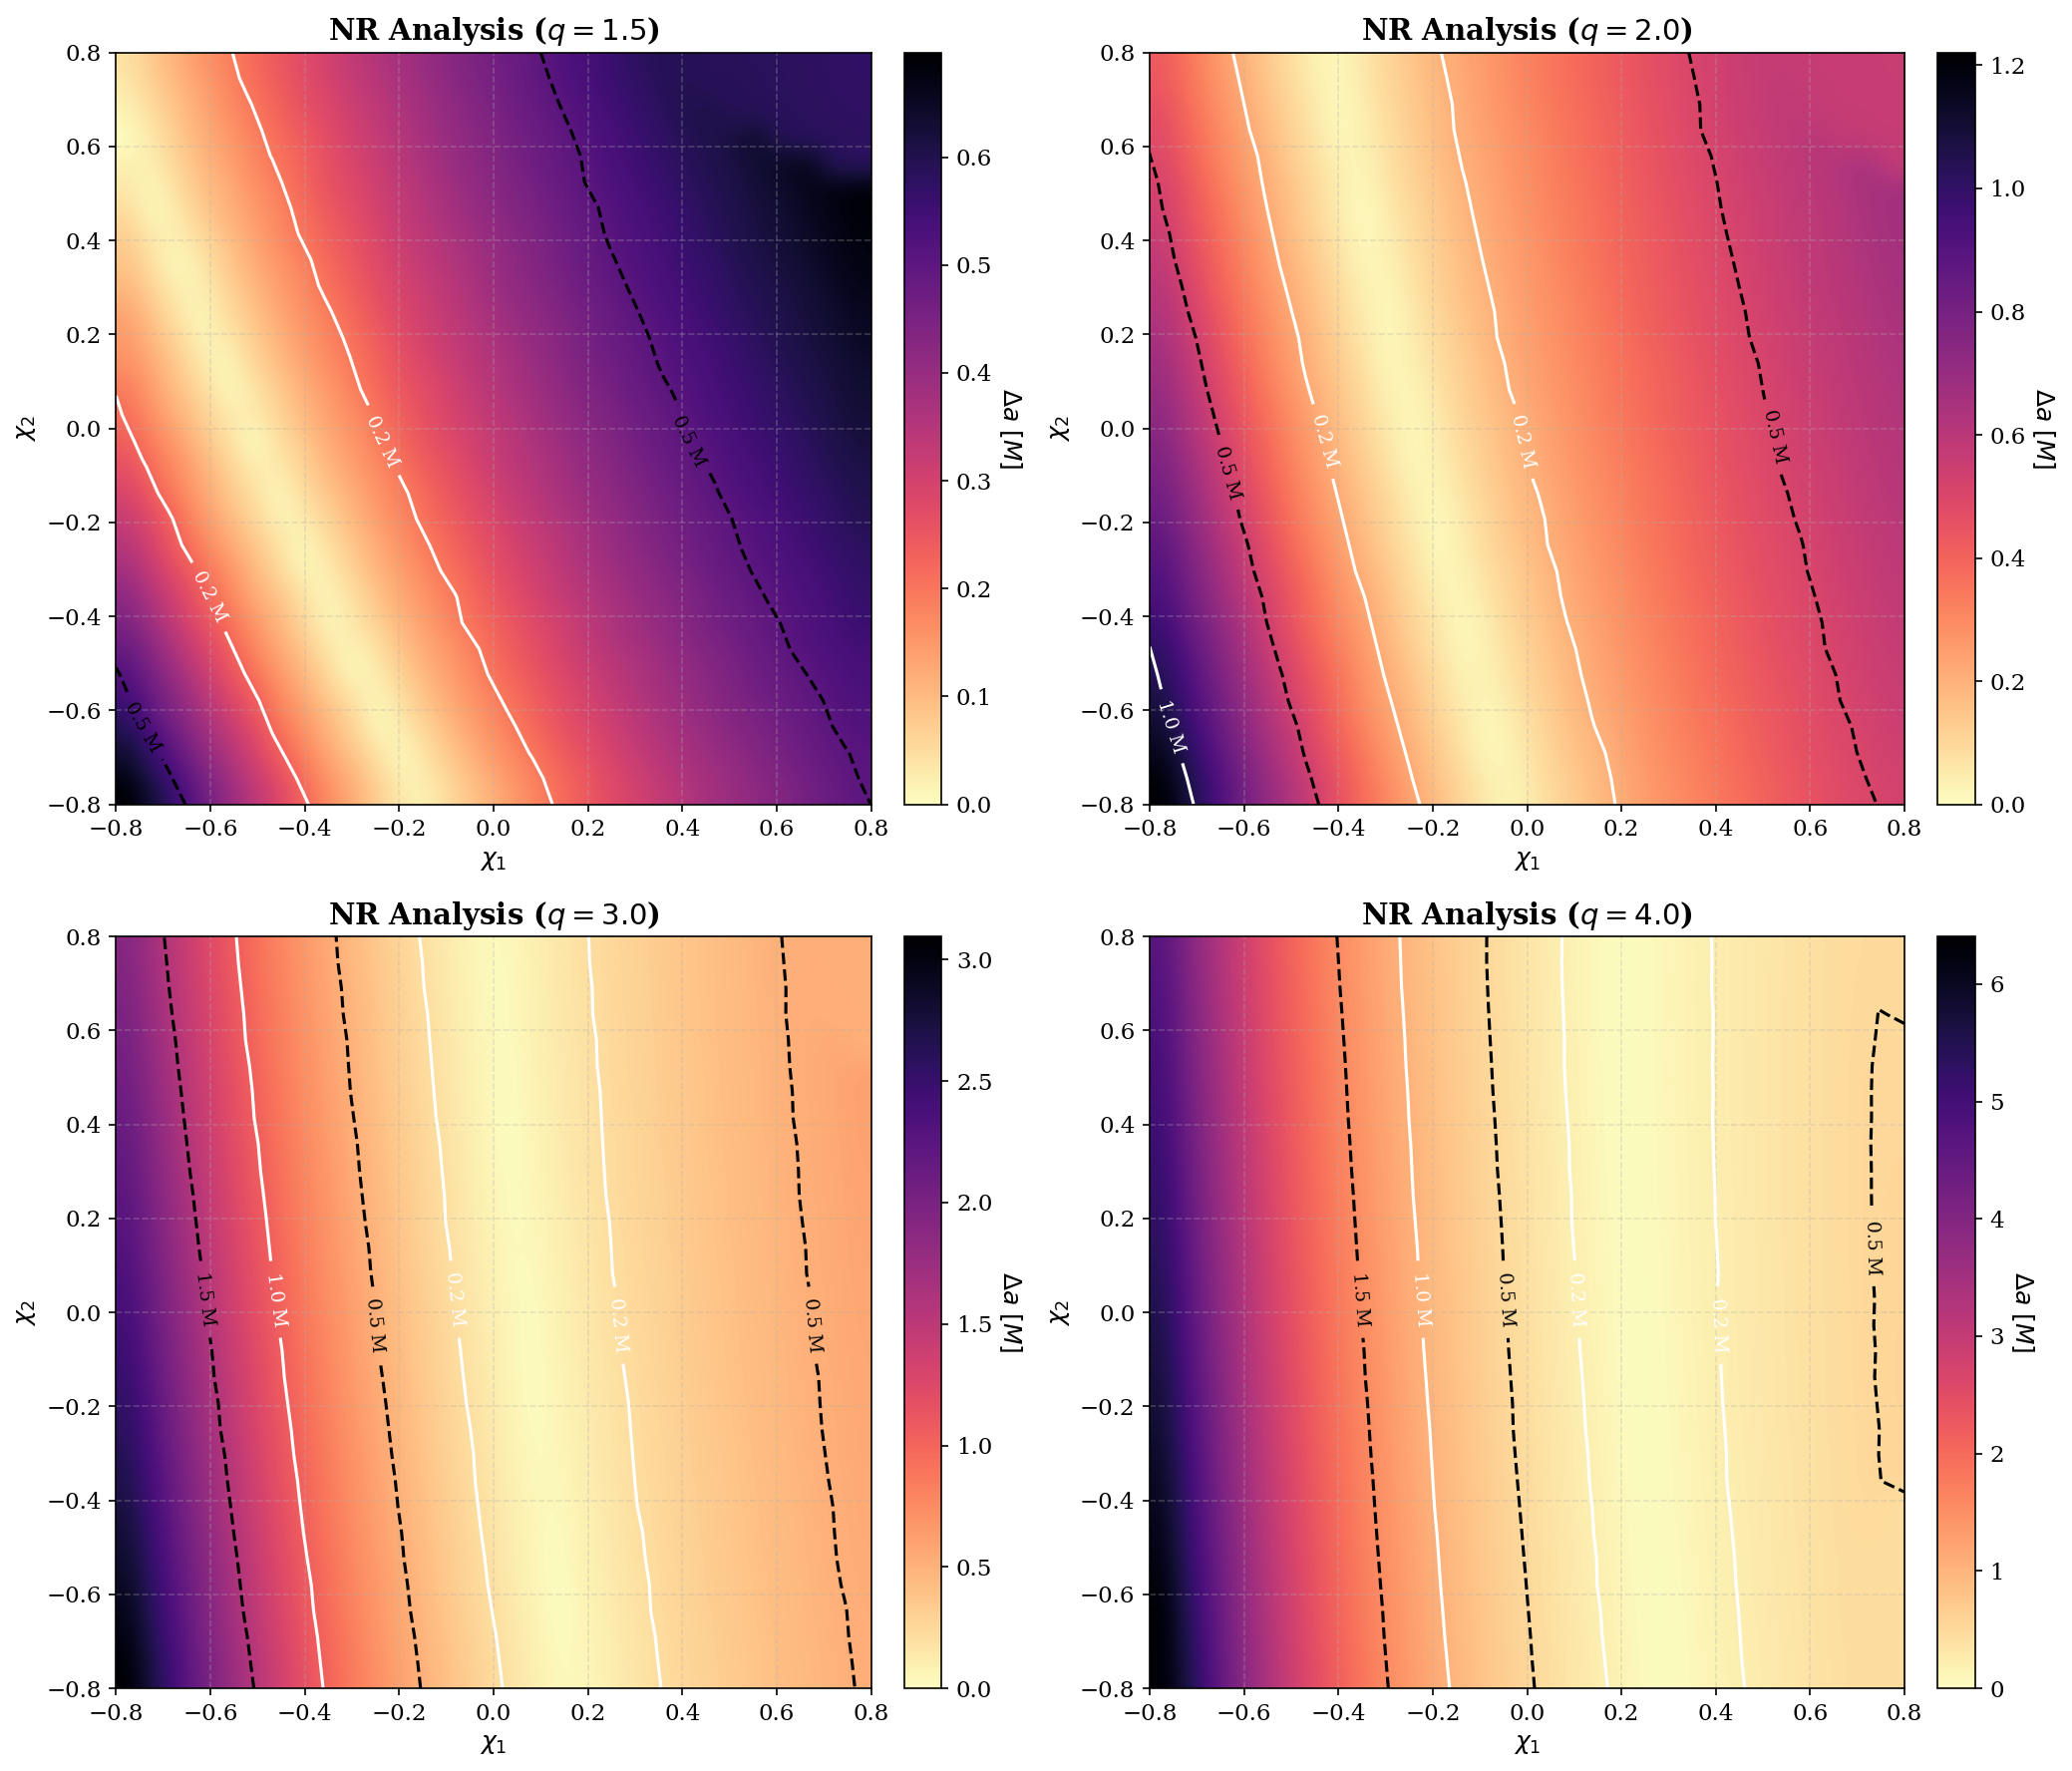

In [203]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "axes.titlesize": 14,
})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12), dpi=150)
axes = axes.flatten()

for idx, q_val in enumerate(q_values):
    ax = axes[idx]
    matrix = results_dict_surrogate[q_val]
    im = ax.imshow(matrix, origin='lower', 
                   extent=[chi_range_NR.min(), chi_range_NR.max(), chi_range_NR.min(), chi_range_NR.max()], 
                   cmap='magma_r', aspect='auto', interpolation='bicubic')

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\Delta a \ [M]$', rotation=270, labelpad=15)
    contours = ax.contour(chi1_grid_NR, chi2_grid_NR, matrix, levels=[0.2, 0.5, 1.0, 1.5], 
                          colors=['white', 'black'], linestyles=['-', '--'], linewidths=1.5)
    ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f M')
    ax.set_xlabel(r'$\chi_1$')
    ax.set_ylabel(r'$\chi_2$')
    ax.set_title(rf'NR Analysis ($q={q_val}$)', fontweight='bold')

plt.tight_layout()
plt.show()